# 0 - Setup & Class Definitions 

In [ ]:
# Model 
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# Utilities 
import random
from typing import Dict, List, Tuple, Optional,Any, Type, Callable, TypeVar
from dataclasses import dataclass, field
from enum import Enum
from random import seed

# RL 
import gymnasium as gym
from gymnasium import spaces

## (i) NetworkX Extension

In [538]:
class NodeState(Enum):
    SUSCEPTIBLE = 0 
    INFECTED = 1

## NetworkX Extension 
class InformationNetwork(nx.DiGraph):
    """
        Extended directed graph for information spread modeling.
        We extend the model to to add states to nodes and weight to edges automatically. 
    """
    
    def __init__(self, *args, **kwargs):
        self.type = "None"
        super().__init__(*args, **kwargs)
    
    def add_node(self, node_for_adding, **attr):
        """Add a node with SIR state, skepticism, infection length attributes."""
        if 'state' not in attr:
            attr['state'] = NodeState.SUSCEPTIBLE
        if 'skepticism' not in attr: 
            attr['skepticism'] = random.random()
        if 'length_of_infection' not in attr: 
            attr['length_of_infection'] = 0 
        super().add_node(node_for_adding, **attr)
    
    def add_edge(self, u_of_edge, v_of_edge, **attr):
        """Add an edge with weight attribute."""
        if 'weight' not in attr:
            attr['weight'] = 1.0 # Default weight: 1 
        super().add_edge(u_of_edge, v_of_edge, **attr)

    # Visualization 
    # TODO: Add Graphs as well 
    def visualize(self):
        """
            Visualize the current state of the network.
        """
        # Create a color map based on node states
        colors = {
            NodeState.SUSCEPTIBLE: 'blue',
            NodeState.INFECTED: 'red', 
        }
        
        node_colors = [colors[self.nodes[n]['state']] for n in self.nodes()]
        
        # Get edge weights for visualization
        edge_weights = [self[u][v]['weight'] for u, v in self.edges()]
        
        # Create the visualization
        pos = nx.spring_layout(self)
        plt.figure(figsize=(10, 8))
        
        nx.draw_networkx_nodes(self, pos, node_color=node_colors, alpha=0.8)
        nx.draw_networkx_edges(self, pos, width=edge_weights, alpha=0.5)
        nx.draw_networkx_labels(self, pos)
        
        plt.title("Information Network State")
        plt.axis('off')
        plt.show()    
    


In [539]:

class NetworkGenerator:
    """Class for generating synthetic networks for testing."""
    
    @staticmethod
    def erdos_renyi(n: int, p: float) -> InformationNetwork:
        """Generate an Erdos-Renyi random graph."""
        network = InformationNetwork()
        network.type = "erdos_renyi"
        graph = nx.erdos_renyi_graph(n, p, directed=True)
        
            # Add nodes with state attribute
        for node in graph.nodes():
                network.add_node(node, 
                                state=NodeState.SUSCEPTIBLE,
                                skepticism=np.random.beta(3, 7),  # Values between 0-1
                                infection_length=0)
        # Add weighted edges
        for u, v in graph.edges():
            # Random weight between 0 and 1
            weight = np.random.random()
            network.add_edge(u, v, weight=weight)
            
        return network
    
    @staticmethod
    def scale_free(n: int, m: int) -> InformationNetwork:
        """Generate a scale-free network using preferential attachment."""
        # Create empty network
        network = InformationNetwork()
        network.type = "scale_free"

        # Create the networkx graph 
        graph = nx.barabasi_albert_graph(n, m)
        

        
        # Add all nodes with COMPLETE initialization
        for node in graph.nodes():
            network.add_node(node, 
                            state=NodeState.SUSCEPTIBLE,
                            skepticism=np.random.beta(3, 7),  # Values between 0-1
                            infection_length=0)
        
        # Add edges with random directions and weights
        for u, v in graph.edges():
            if np.random.random() > 0.5:
                weight = np.random.random()
                network.add_edge(u, v, weight=weight)
            else:
                weight = np.random.random()
                network.add_edge(v, u, weight=weight)
        
        return network
        
    @staticmethod
    def small_world(n: int, k: int, p: float) -> InformationNetwork:
        """Generate a small-world network."""
        network = InformationNetwork()
        network.type = "small_world"
        graph = nx.watts_strogatz_graph(n, k, p)
        
        for node in graph.nodes():
                network.add_node(node, 
                                state=NodeState.SUSCEPTIBLE,
                                skepticism=np.random.beta(3, 7),  # Values between 0-1
                                infection_length=0)
        
        # Convert to directed graph by choosing random directions
        for u, v in graph.edges():
            # Choose direction randomly
            if np.random.random() > 0.5:
                weight = np.random.random()
                network.add_edge(u, v, weight=weight)
            else:
                weight = np.random.random()
                network.add_edge(v, u, weight=weight)
            
        return network




## (ii) Node/Network State Features Handling

In [540]:
# Type definition for the extractor function
NetworkType = TypeVar('NetworkType') # Generic type for network nodes
NodeID = TypeVar('NodeID')  # Type for node IDs (typically int or str)
ExtractorFunc = Callable[[NetworkType], Dict[NodeID, float]] 

# Feature Registry and feature pipeline 
class FeatureRegistry:
    """
        Registry that automatically assigns indices to features at runtime
    """
    _feature_indices: Dict[str, int] = {}
    _feature_extractors: Dict[str, int] = {}
    _next_index: int = 0
    
    @classmethod
    def reset(cls):
        """
            Reset the registry
        """
        cls._feature_indices = {}
        cls._feature_extractors = {}
        cls._next_index = 0
    
    @classmethod
    def register(cls, feature_name: str, extractor: Optional[ExtractorFunc]) -> int:
        """
            Register a feature and get its index
            TODO: Add an extractor. 
        """
        if feature_name not in cls._feature_indices:
            cls._feature_indices[feature_name] = cls._next_index
            cls._next_index += 1
        
        if extractor is not None:
            cls._feature_extractors[feature_name] = extractor
            
        return cls._feature_indices[feature_name]
    
    @classmethod
    def get_extractor(cls, feature_name: str) -> ExtractorFunc:
        """Get a feature's extractor function"""
        if feature_name not in cls._feature_extractors:
            raise ValueError(f"No extractor for feature '{feature_name}'")
        return cls._feature_extractors[feature_name]
    
    @classmethod
    def extract_feature(cls, feature_name: str, network: NetworkType) -> Dict[int, float]:
        """
            Extract a feature value from a network

            Returns: 
                A Dictionary of feature values indexed by node_id
        """
        if feature_name not in cls._feature_extractors: 
            raise ValueError(f"No extractor for feature '{feature_name}'")
        extractor = cls.get_extractor(feature_name)
        return extractor(network)
    
    @classmethod
    def extract_all_features(cls, network: NetworkType) -> Dict[str, Dict]:
        """
            Extract all feature values from a network.
            Return: 
                Dictionary of Feature
        """
        return {
            name: cls.extract_feature(name, network) 
            for name in cls._feature_extractors.keys()
        }

    @classmethod
    def extract_feature_matrix(cls, network, **kwargs) -> Tuple[np.ndarray, List[NodeID]]:
        """
        Create a feature matrix with consistent node ordering
        
        Returns:
            Tuple containing:
            - Feature matrix of shape (num_nodes, num_features)
            - List of node IDs in the order they appear in the matrix
        """
        # Extract all features
        all_features = cls.extract_all_features(network, **kwargs)
        
        # Get all unique node IDs from first feature (assuming all features cover same nodes)
        node_ids = network.nodes.keys()

        # Sort node IDs for consistent ordering across calls
        # TODO: If there is a mysterious bug, this is a good place to look. 
        node_ids = list(network.nodes())
        
        # Create feature matrix
        num_nodes = len(node_ids)
        num_features = len(cls._feature_indices)
        feature_matrix = np.zeros((num_nodes, num_features))
        
        # Fill feature matrix
        for feature_name, feature_dict in all_features.items():
            feature_idx = cls._feature_indices[feature_name]
            for i, node_id in enumerate(node_ids):

                # Return default value 0.0 if for whatever reason key is gone. 
                feature_matrix[i, feature_idx] = feature_dict.get(node_id, 0.0)
        
        return feature_matrix, node_ids
    
    @classmethod
    def get_index(cls, feature_name: str) -> int:
        """
            Get a feature's index
            Args: 
                feature_name: str, name of the feature. 
            Return:
                Index of feature in registry. 
        """
        if feature_name not in cls._feature_indices:
            raise ValueError(f"Feature '{feature_name}' not registered")
        return cls._feature_indices[feature_name]
    
    @classmethod
    def get_all_indices(cls) -> Dict[str, int]:
        """
            Get all registered features and their indices
        """
        return cls._feature_indices.copy()
    
    @classmethod
    def get_feature_count(cls) -> int:
        """
            Get the number of registered features
        """
        return len(cls._feature_indices)


In [541]:

@dataclass #TODO: Frozen = True
class NodeFeature:
    """
        A node feature definition with auto-indexing 
    """
    name: str
    typeription: str = ""
    extractor: ExtractorFunc = None
    
    _index: int = field(default=None, init=False, repr=True)
    
    def __post_init__(self):
        # Even though the class is frozen, we can modify via object.__setattr__
        feature_index = FeatureRegistry.register(self.name, self.extractor)
        print("Setting Attribute")
        object.__setattr__(self, '_index', feature_index)
    
    @property
    def index(self) -> int:
        return self._index

## (iii) Feature Definitions

In [ ]:
# TODO: Continue Here

class FeatureExtractors(): 
    """
        This is the interface between our Network and the model agents/training 
        How this works: 
            1 - Create a (private) static method for each feature we want 
            2 - 
    """

    @staticmethod
    def get_state(network: InformationNetwork) -> Dict[int,float]: 
        """
            States of all nodes in the network, according to NodeState class. 
            Returns: 
                Dict[index_id,normalized_state_value]
        """

        # States Dictionary 
        return {node: network.nodes[node]['state'].value for node in network.nodes} 

    @staticmethod
    def get_skepticism(network: InformationNetwork) -> Dict[int,float]: 
        return {node: network.nodes[node]['skepticism'] for node in network.nodes}

    @staticmethod
    def get_length_of_infection(network: InformationNetwork) -> Dict[int,float]: 
        lengths = {node: network.nodes[node]['length_of_infection']
                    for node in network.nodes}
        max_length = max(lengths.values() if lengths else 1) # Normalization factor  
        if max_length == 0: max_length = 1
        return {node: network.nodes[node]['length_of_infection']/max_length for node in network.nodes}

    @staticmethod 
    def get_internal_influence(network: InformationNetwork) -> Dict[int,float]:
        """
            Internal influence of infected nodes within the infected subnetwork. 

            Returns: 
                Dict[node_id, internal_influence] 
        """
        infected_nodes = [n for n, d in network.nodes(data=True) if d['state'] == NodeState.INFECTED]
        
        # Feature 1: Internal influence -- how influential an infected node is 
        # within the subnetwork of infected nodes. 
        internal_influence = {node: 0.0 for node in network.nodes} 

        if len(infected_nodes) > 2:  # Need at least 3 nodes for meaningful eigenvector centrality
            infected_subgraph = network.subgraph(infected_nodes)
            
            try:
                # Try using NetworkX's eigenvector_centrality with full matrix
                subgraph_influence = nx.eigenvector_centrality(
                    infected_subgraph,
                    max_iter=1000,
                    tol=1e-06,
                    weight='weight'
                )
                internal_influence.update(subgraph_influence)
            except Exception as e:
                # Use degree centrality as fallback
                # For example if sub-graph is disconnected
                print(f"Falling back to degree centrality: {str(e)}")
                subgraph_influence = nx.degree_centrality(infected_subgraph)
                internal_influence.update(subgraph_influence)

        return internal_influence
    
    @staticmethod 
    def get_infection_pressure(network: InformationNetwork) -> Dict[int,int]: 
        """
        Node feature
        Calculate (normalized) infection pressure on susceptible nodes 
        (weighted sum of number of incoming infected neighbors) 

        Returns: 
            Dict[node_id,infection_pressure]

        """
        infection_pressure = {node: 0.0 for node in network.nodes} 
        for node in network.nodes:
            in_degree = network.in_degree(node, weight='weight')
            if network.nodes[node]['state'] == NodeState.SUSCEPTIBLE and in_degree > 0: 
                weighted_pressure = sum(network[pred][node]['weight']
                                        for pred in network.predecessors(node)
                                        if network.nodes[pred]['state'] == NodeState.INFECTED) / in_degree
                infection_pressure[node] = weighted_pressure       
        return infection_pressure
    
    @staticmethod
    def get_spreading_potential(network: InformationNetwork) -> Dict[int,int]: 
        """
            Node feature
            Identify nodes that are most likely to spread infection 
            (infected nodes with many susceptible neighbors) 

            Returns: 
                Dict[node_id,spreading_potential]
        """

        spreading_potential = {node: 0.0 for node in network.nodes} 
        infected_nodes = [n for n, d in network.nodes(data=True) if d['state'] == NodeState.INFECTED]
        for node in infected_nodes: 
            out_degree = network.out_degree(node, weight='weight')
            if out_degree > 0:
                weighted_potential = sum(network[node][succ]['weight']
                                        for succ in network.successors(node)
                                        if network.nodes[succ]['state'] == NodeState.SUSCEPTIBLE)
                spreading_potential[node] = weighted_potential / out_degree
        
        return spreading_potential


In [543]:
# NOTE: This is where features are registered for the Gym Environment.
@dataclass
class NodeFeatures:
    """
        Collection of feature definitions
    """
    # Reset registry when class is loaded
    FeatureRegistry.reset()
    
    # Features will be automatically indexed in the order defined
    STATE = NodeFeature(name="state", typeription="Node infection state",
                        extractor=FeatureExtractors.get_state)
    SKEPTICISM = NodeFeature(name="skepticism", extractor=FeatureExtractors.get_skepticism)
    LENGTH_OF_INFECTION = NodeFeature(name="length_of_infection", extractor=FeatureExtractors.get_length_of_infection)
    INTERNAL_INFLUENCE = NodeFeature(name="internal_influence",
                        extractor=FeatureExtractors.get_internal_influence)
    INFECTION_PRESSURE = NodeFeature(name="infection_pressure",
                                    extractor=FeatureExtractors.get_infection_pressure)
    SPREADING_POTENTIAL = NodeFeature(name="spreading_potential",
                                    extractor=FeatureExtractors.get_spreading_potential)
    
    @classmethod
    def get_all(cls) -> List[NodeFeature]:
        """
            Get all feature definitions
        """
        return [
            cls.STATE, 
            cls.INTERNAL_INFLUENCE,
            cls.SKEPTICISM,
            cls.LENGTH_OF_INFECTION,
            cls.INFECTION_PRESSURE,
            cls.SPREADING_POTENTIAL
        ]

Setting Attribute
Setting Attribute
Setting Attribute
Setting Attribute
Setting Attribute
Setting Attribute


In [544]:
import IPython.display as display
import time

# 2 - RL Environment

In [545]:
import ray
from copy import copy
from ray import tune 
from ray.tune.logger import pretty_print
from ray.tune.registry import register_env
from ray.rllib.algorithms.callbacks import DefaultCallbacks
from ray.rllib.algorithms import Algorithm
from ray.rllib.algorithms.ppo import PPOConfig
from ray.rllib.policy.policy import PolicySpec
from ray.rllib.env.multi_agent_env import MultiAgentEnv
from ray.rllib.env.wrappers.multi_agent_env_compatibility import MultiAgentEnvCompatibility

In [ ]:
class MultiAgentNetworkEnv(MultiAgentEnv):
    """
        We define a multi-agent wrapper for the environment. 
        This allows us to e.g. decouple observations between agents down the lines. 
        
        This also follows Ray RLLib's best practices for MARL. 
    """
    def __init__(self, net_env_config: NetworkEnvironmentConfig):
        super(MultiAgentNetworkEnv, self).__init__()  # Correct way

    # Initialize with network config
    # Handle either config object or dictionary
        if isinstance(net_env_config, dict):
            self.config = NetworkEnvironmentConfig.from_dict(net_env_config)
        else:
            # Direct object was passed
            self.config = net_env_config

        self.possible_agents = ['agent_a','agent_b'] # Not sure which one I need. 
        self._agent_ids = ['agent_a','agent_b']
        
        # Set up action and observation spaces for agents
        self.action_space = self.config.get_action_space()
        self.observation_space = self.config.get_observation_space()

        # Underlying (Social) Network 
        self.network = self.config.get_information_network()

        # Model Parameters  
        self.initial_infection_density = self.config.initial_infection_density
        self.infection_prob = self.config.infection_probability
        self.recovery_prob = self.config.recovery_probability



        # Simulation Parameters 
        self.max_steps = self.config.max_steps
        self.num_nodes = self.config.num_nodes
        self.current_step = 1 # Just to avoid div by zero
        self.max_action_radius = self.config.max_action_radius
        
        # Initial Infections
        nodes = list(self.network.nodes())
        np.random.shuffle(nodes)
        target_count = int(self.initial_infection_density * self.num_nodes)
        
        for i in range(target_count):
            if i < len(nodes):
                self.network.nodes[nodes[i]]['state'] = NodeState.INFECTED

        # Simulation Data 
        self.current_infection_rate = 0
        self.previous_infection_rate = 0 
        self.node_ids = []
        
    def reset(self, *, seed=None, options=None):
        # Reset all nodes to susceptible
        for node_id in self.network.nodes():
            self.network.nodes[node_id]['state'] = NodeState.SUSCEPTIBLE
        
        self.current_step = 1
        obs = self._get_observation()

        # return observation dict and infos dict.
        return {
            "agent_a": obs,
            "agent_b": obs
        }, {} # Empty infos dict. 
    
    def step(self, action_dict):
        # Record initial state
        self.previous_infection_rate = self.current_infection_rate 

        # Unpack actions from both agents
        action_a = action_dict["agent_a"]
        action_b = action_dict["agent_b"]
        
        # First execute Agent A's action (infection) 
        # & Agent B's action (prevention)
        self._execute_action_a(action_a)
        self._execute_action_b(action_b)

        # Then process information propagation 
        # Returns array of all nodes that were infected 
        self.newly_infected_nodes = self._propagate_information() 

        # Then process recovery 
        self.newly_recovered_nodes = self._process_recovery()

        # Update step counter += 1 
        self.current_step += 1 

        # Update infection lengths
        for node in self.network.nodes:
            if self.network.nodes[node]['state'] == NodeState.INFECTED: 
                self.network.nodes[node]['length_of_infection'] +=1 

        # Update edge weights 
        # 5% edge weight increase
        for u, v in self.network.edges():
            if (self.network.nodes[u]['state'] == NodeState.INFECTED and 
                self.network.nodes[v]['state'] == NodeState.INFECTED):
                # Reinforcement of connections between infected nodes
                self.network[u][v]['weight'] = min(1.0, self.network[u][v]['weight'] * 1.05)
        # Update data 
        self.last_infection_rate = self.current_infection_rate
        self.current_infection_rate = self._get_infection_rate()

        # Get observation 
        # This will be the feature matrix of this network 
        obs = self._get_observation()

        # Calculate Rewards 
        reward_a = self._calculate_reward_a()
        reward_b = self._calculate_reward_b()
        
        # Check if the episode is done 
        done = self._is_done() 

        # Get custom metrics
        custom_metrics = self._get_episode_info()
        
        # Add metrics to info dict
        infos = {
            "agent_a": {"metrics": custom_metrics},
            "agent_b": {"metrics": custom_metrics}
        }
            
        # Format for multi-agent environment
        observations = {
            "agent_a": obs,
            "agent_b": obs
        }
        rewards = {
            "agent_a": reward_a,
            "agent_b": reward_b
        }
        terminateds = {
            "agent_a": done,
            "agent_b": done,
            "__all__": done
        }
        
        # New Gymnasium API requires "truncateds" to indicate time limit cutoffs
        # (false if terminated normally, true if cut off by time limit)
        # We don't use this so just set all to false. 
        truncateds = {
            "agent_a": False,
            "agent_b": False,
            "__all__": False
        }
        
        return observations, rewards, terminateds, truncateds, infos

    def action_space_sample(self, agent_ids=None):
        """Override to provide proper action space sampling.
        
        Args:
            agent_ids: Optional list of agent IDs to sample for
                    If None, sample for all agents
        
        Returns:
            Dictionary mapping agent IDs to sampled actions
        """
        if agent_ids is None:
            agent_ids = self.possible_agents
            
        return {
            agent_id: self.action_space[agent_id].sample()
            for agent_id in agent_ids
        }

    def observation_space_sample(self, agent_ids=None):
        """Override to provide proper observation space sampling.
        
        Args:
            agent_ids: Optional list of agent IDs to sample for
                    If None, sample for all agents
        
        Returns:
            Dictionary mapping agent IDs to sampled observations
        """
        if agent_ids is None:
            agent_ids = self.possible_agents
            
        return {
            agent_id: self.observation_space[agent_id].sample()
            for agent_id in agent_ids
        }
    
    # Local model controller functions  
    def _execute_action_a(self, action): 
        """
            Execute Agent A's action (infection).
            Args: 
                action: ID of node to infect.
        """
        node_id = action['node_id']

        if node_id not in self.network: 
            raise ValueError(f"Invalid node {node_id} passed to Agent A (Spreader")
        
        node_data = self.network.nodes[node_id]
    
        # If node is susceptible and infection threshold is reached:
        # Skeptical nodes are less likely to be infected. 
        eff_prob = self.infection_prob * (1 - node_data['skepticism'])
        self._infect_node(node_id, eff_prob)

    def _execute_action_b(self, action): 
        radius = min(action['radius'], self.max_action_radius)
        center_node = action['node_id']

        if center_node not in self.network.nodes: 
            raise ValueError(f"Invalid node {center_node} passed to Agent B (Healer)")
                
        # Identify the subnetwork (BFS to specified radius)
        if radius == 0: 
            self._heal_node(center_node, self.recovery_prob) # TODO: Add Community effects to recovery.

        elif radius > 0:
            subnetwork = set([center_node])
            frontier = set([center_node])
            for r in range(radius):
                next_frontier = set()
                for node in frontier:
                    for succ_node in self.network.successors(node):
                        # Slow down infection spread within a 2 step redius. 
                        # This is also weighted by radius 
                        self.network[node][succ_node]['weight'] *= 0.85 * (3 - r)/3

                        # Do the same for skepticism 
                        new_skept = min(
                          1, 
                          self.network.nodes[node]['skepticism'] * (1 + 0.10*(self.max_action_radius - r)/self.max_action_radius)
                          )
                        self.network.nodes[node]['skepticism'] = new_skept


                    # Add neighbors that aren't already in subnetwork
                    next_frontier.update(
                        [n for n in self.network.successors(node) 
                        if n not in subnetwork]
                    )
                subnetwork.update(next_frontier)
                frontier = next_frontier

        # TODO: Max on size of subnetwork? 

    def _propagate_information(self):
        """
            Propagate information through the network using SIR model.
            Returns: 
                [node_id]: All newly infected nodes 
            
            # TODO: Include community based propagation rates
        """
        new_infections = []

        # Infection process
        # For each infected node
        for node_id in self.network.nodes:
            if self.network.nodes[node_id]['state'] != NodeState.INFECTED:
                continue
            
            skepticism = self.network.nodes[node_id]['skepticism']

            # Attempt to infect each susceptible neighbor
            for neighbor_id in self.network.successors(node_id):
                if self.network.nodes[neighbor_id]['state'] != NodeState.SUSCEPTIBLE:
                    continue
                
                # Use edge weight to influence probability
                edge_weight = self.network[node_id][neighbor_id]['weight']
                eff_prob = self.infection_prob * (1 - skepticism) * edge_weight

                # Attempt infection
                if self._infect_node(neighbor_id, eff_prob):
                    new_infections.append(neighbor_id) 
        
        return new_infections
    
    def _process_recovery(self):
        """
            Propagate recovery through neighboring edges 
            Returns: 
                [node_id]: All newly recovered nodes 
            TODO Implement the network recovery logic
        """
        recoveries = []
        # Recovery process
        # For each infected node, there's a chance to recover
        for node_id in self.network.nodes:
            if (self.network.nodes[node_id]['state'] == NodeState.INFECTED 
                and node_id not in self.newly_infected_nodes):
                duration = self.network.nodes[node_id]['length_of_infection']
                eff_recovery_prob = self.recovery_prob /(1 + 0.1 * duration)
                if self._heal_node(node_id, eff_recovery_prob): 
                    recoveries.append(node_id)
        
        return recoveries

    def _get_observation(self):
        """
            Generate observation based on current network state.

            Returns: 
                ndarray of shape (num_nodes, num_features) 
        """
        # Node IDs is a mapping of nodes to their respective indices
        feature_matrix, node_ids = FeatureRegistry.extract_feature_matrix(self.network)
        self.node_ids = node_ids
        
        return feature_matrix

    def _calculate_reward_a(self):
        infection_change = self.current_infection_rate - self.previous_infection_rate
        
        # Base reward on infection growth
        growth_reward = infection_change * 20.0  # Scaling factor
        
        # Add small reward for maintaining high infection
        persistence_reward = self.current_infection_rate * 2.0
        
        return growth_reward + persistence_reward 
          

    def _calculate_reward_b(self):
        current_infection_rate = self._get_infected_count() / self.num_nodes
        infection_change = current_infection_rate - self.previous_infection_rate
        
        # Base reward on infection reduction
        containment_reward = -infection_change * 20.0  # Negative change is good
        
        # Bonus for keeping infection rate low
        low_infection_bonus = (1.0 - current_infection_rate) * 2.0

        return containment_reward + low_infection_bonus
    
    def _is_done(self):
        """Check if episode is done."""
        # Episode ends if:
        # 1. Max steps reached
        # 2. No susceptible nodes left
        # 3. No infected nodes left (infection contained)
        
        if self.current_step >= self.max_steps:
            return True
        
        susceptible_count = self._get_susceptible_count()
        infected_count = self._get_infected_count()
        
        if (self._get_susceptible_count() == 0 
            or self._get_infected_count() == 0):
            return True
        
        return False
    
    def _get_episode_info(self):
        """Calculate episode metrics specific to information spread."""
        # Network state metrics
        infected_count = self._get_infected_count()
        infection_rate = infected_count / self.num_nodes
        
        # Calculate clustering of infected nodes
        infected_nodes = [n for n, d in self.network.nodes(data=True) 
                        if d['state'] == NodeState.INFECTED]
        infected_clustering = 0
        if len(infected_nodes) > 2:
            infected_subgraph = self.network.subgraph(infected_nodes)
            infected_clustering = nx.transitivity(infected_subgraph)
        
        # Calculate average infection duration
        avg_infection_duration = np.mean([
            self.network.nodes[n].get('infection_length', 0) 
            for n in infected_nodes
        ]) if infected_nodes else 0
        
        # Structural metrics
        largest_component_size = 0
        if infected_nodes:
            infected_subgraph = self.network.subgraph(infected_nodes)
            largest_cc = max(nx.connected_components(infected_subgraph.to_undirected()), 
                            key=len)
            largest_component_size = len(largest_cc) / len(infected_nodes)
        
        # Intervention effectiveness
        healing_success_rate = (len(self.newly_recovered_nodes) / 
                            max(1, self._get_infected_count() + len(self.newly_recovered_nodes)))
        
        # Return dictionary of metrics
        return {
            "infection_rate": infection_rate,
            "infected_clustering": infected_clustering,
            "avg_infection_duration": avg_infection_duration,
            "largest_component_ratio": largest_component_size,
            "healing_success_rate": healing_success_rate,
            "new_infections": len(self.newly_infected_nodes),
            "new_recoveries": len(self.newly_recovered_nodes)
        }    

    def _get_infected_count(self):
        """
            Get the number of infected nodes.
        """
        return sum(1 for _, data in self.network.nodes(data=True) 
                  if data['state'] == NodeState.INFECTED)
    
    def _get_susceptible_count(self):
        """
            Get the number of susceptible nodes.
        """
        return sum(1 for _, data in self.network.nodes(data=True) 
                  if data['state'] == NodeState.SUSCEPTIBLE)
    
    def _get_infection_rate(self): 
        return self._get_infected_count()/self.num_nodes
    
    def _heal_node(self, node_id: int, prob: float) -> bool:
        """
            Heal nodes in node_ids with probability prob. 
            Returns: 
                success (True) or failure (False)
        """
        if node_id not in self.network.nodes: 
            raise ValueError(f'Node {node_id} not found.')
        
        if random.random() < prob and self.network.nodes[node_id]['state'] == NodeState.INFECTED:     
            self.network.nodes[node_id]['length_of_infection'] = 0 
            self.network.nodes[node_id]['state'] = NodeState.SUSCEPTIBLE

            # Strongly reduce weights of infected nodes. 
            for pred in self.network.predecessors(node_id): 
                self.network[pred][node_id]['weight'] *= 0.1 
            return True 
        
        return False

    def _infect_node(self, node_id: np.ndarray, prob: float) -> bool: 
        """
            Infect nodes in node_ids with probability prob. 
            Returns: 
                successful infection (True) or failure (False)
        """       
        if node_id not in self.network.nodes: 
            raise ValueError(f'Node {node_id} not found.')
        
        if random.random() < prob and self.network.nodes[node_id]['state'] == NodeState.SUSCEPTIBLE: 
            self.network.nodes[node_id]['state'] = NodeState.INFECTED
            return True 
        
        return False
                
    def render(self):
        """Render the environment."""
        self.network.visualize()

def env_creator(env_config):
    return MultiAgentNetworkEnv(env_config)



# 3 - Agent Training 

In [547]:
from ray.rllib.algorithms.callbacks import DefaultCallbacks
import numpy as np
            # "infection_rate": infection_rate,
            # "infected_clustering": infected_clustering,
            # "avg_infection_duration": avg_infection_duration,
            # "largest_component_ratio": largest_component_size,
            # "healing_success_rate": healing_success_rate,
            # "new_infections": len(self.newly_infected_nodes),
            # "new_recoveries": len(self.newly_recovered_nodes)
class InfoSpreadCallbacks(DefaultCallbacks):
    def on_episode_step(self, *, worker, base_env, episode, **kwargs):
        """Called on each episode step."""
        # Safe way to access environment
        infos = episode.last_info_for("agent_a")
        try:
            for key,val in infos["metrics"].items():     
                # Initialize if needed
                if key not in episode.user_data:
                    episode.user_data[key] = []
                
                # Store current rate
                episode.user_data[key].append(val)
                
                # Add as custom metric
                episode.custom_metrics[key] = val
            
        
        except Exception as e:
            print(f"Error in callback: {e}")
    
    def on_episode_end(self, *, worker, base_env, policies, episode, **kwargs):
        """Called at the end of an episode."""
        try:
            # Get infection rates from episode data
            infection_rates = episode.user_data.get("infection_rates", [])
            
            if infection_rates:
                # Calculate metrics
                episode.custom_metrics["infection_auc"] = sum(infection_rates) / len(infection_rates)
                episode.custom_metrics["final_infection_rate"] = infection_rates[-1]
                
                # Add change from start to end if we have multiple points
                if len(infection_rates) > 1:
                    episode.custom_metrics["infection_change"] = infection_rates[-1] - infection_rates[0]
        except Exception as e:
            print(f"Error in episode end callback: {e}")

## (i) Simultaneous Training

In [ ]:

# 0. Define Constants  
N_NODES = 50 
INFECTION_PROB = 0.5 
RECOVERY_PROB = 0.05
MAX_STEPS = 100

# 1. Initialize Ray
ray.shutdown()
ray.init()

# Register the environment with Ray
register_env("network_spread", env_creator)

# Create training environment config 
train_env_config = NetworkEnvironmentConfig(
    network_type = "small_scale", 
    nx_n = N_NODES,
    nx_m = 3,
    num_nodes = N_NODES, 
    num_features = FeatureRegistry.get_feature_count(),
    initial_infection_density = 0.5,
    infection_probability = INFECTION_PROB, 
    recovery_probability = RECOVERY_PROB, 
    max_steps = MAX_STEPS, 
    max_action_radius = 1 
)

# Prepare to pass to configuration for RLLib
env_config_dict = train_env_config.to_dict()

# Then use its observation spaces in the config
config = (
    PPOConfig()
    .environment("network_spread", env_config=env_config_dict)
    .multi_agent(
        policies={
            "agent_a": PolicySpec(
                observation_space=train_env_config.get_observation_space().get("agent_a"),
                action_space=train_env_config.get_action_space().get("agent_a") 
            ),
            "agent_b": PolicySpec(
                observation_space=train_env_config.get_observation_space().get("agent_b"),
                action_space=train_env_config.get_action_space().get("agent_b") 
            )
        },
        policy_mapping_fn=lambda agent_id, *args, **kwargs: agent_id
    )
    .framework("torch")
    .training(
        train_batch_size=4000,
        lr=5e-5,
        
        gamma=0.99,
        lambda_=0.95,
        entropy_coeff=0.2,
    )
    .rollouts(
        num_rollout_workers=4,
        rollout_fragment_length=100
    )
    .debugging(log_level="WARNING")
    .callbacks(InfoSpreadCallbacks)

    # Add TensorBoard for visualization
    .reporting(
        keep_per_episode_custom_metrics=True,
    )
)



In [ ]:
# Run training with monitoring
def stats_along_columns(inhomogenous_array):
    max_length = max([len(row) for row in inhomogenous_array])
    means = np.zeros(max_length)
    medians = np.zeros(max_length)
    stds = np.zeros(max_length) 

    for col in range(max_length):
        col_vals = []
        for row in inhomogenous_array:
            if len(row) >= col + 1: 
                col_vals.append(row[col])
        if col_vals:
            means[col] = np.mean(col_vals)
            medians[col] = np.median(col_vals)
            stds[col] = np.std(col_vals)

    return {
        'means': means,
        'medians': medians, 
        'stds': stds 
    }

NUM_ITERATIONS = 100
"""Run experiment with comprehensive monitoring."""
# Initialize algorithm
algo = config.build()

# Storage for metrics
metrics_history = {
    "infection_rate": [],
    "healing_success_rate": [],
    "largest_component_ratio": [],
    "avg_infection_duration": [],
    "reward_agent_a": [],
    "reward_agent_b": []
}

# Training loop with metric collection
for i in range(num_iterations):
    result = algo.train()
    
    # Extract and store metrics
    print(f"Iteration {i}:")
    print(f"  Episode reward mean: {result['episode_reward_mean']}")
    
    # Store custom metrics
    for key in metrics_history:
        if key.startswith("reward"):
            agent = key.replace("reward_", "")
            print(key)
            metrics_history[key].append(
                result['policy_reward_mean'][agent]
            )
        elif key in result['custom_metrics']:
            metrics_history[key].append(
                result['custom_metrics'][key]
            )
        print(f"  {key}: {metrics_history[key][-1] if metrics_history[key] else 'N/A'}")
    
# Create visualizations
plt.figure(figsize=(15, 10))
infection_rate_trajectory_stats = stats_along_columns(metrics_history["infection_rate"])
healing_success_rate_trajectory_stats = stats_along_columns(metrics_history["healing_success_rate"])

# Plot 1: Infection rate over time
plt.subplot(2, 2, 1)
plt.plot(infection_rate_trajectory_stats['means'])
plt.title("Infection Rate During Training")
plt.xlabel("Training Iteration")
plt.ylabel("Infection Rate")
plt.grid(True)

# Plot 2: Healing success rate
plt.subplot(2, 2, 2)
plt.plot(healing_success_rate_trajectory_stats['means'])
plt.title("Healing Success Rate")
plt.xlabel("Training Iteration")
plt.ylabel("Success Rate")
plt.grid(True)

# Plot 3: Rewards for both agents
plt.subplot(2, 2, 3)
plt.plot(metrics_history["reward_agent_a"], label="Agent A (Spreader)")
plt.plot(metrics_history["reward_agent_b"], label="Agent B (Healer)")
plt.title("Agent Rewards During Training")
plt.xlabel("Training Iteration")
plt.ylabel("Reward")
plt.legend()
plt.grid(True)
    
    # Plot 4: Network structure metrics
    # plt.subplot(2, 2, 4)
    # plt.plot(np.mean(metrics_history["largest_component_ratio"], axis=1), label="Largest Component")
    # plt.plot(np.mean(metrics_history["avg_infection_duration"], axis=1), label="Avg Infection Duration")
    # plt.title("Network Structure Metrics")
    # plt.xlabel("Training Iteration")
    # plt.ylabel("Value")
    # plt.legend()
    # plt.grid(True)
    
plt.tight_layout()
plt.savefig("training_metrics.png")
plt.show()

# Save the trained policies
checkpoint_path = algo.save()
print(f"Saved checkpoint to: {checkpoint_path}")


KeyboardInterrupt: 

## (ii) Training Evaluation

In [ ]:
def analyze_late_intervention(trained_algo, config, initial_infection_rates=[0.3, 0.5, 0.7]):
    """Run and analyze late intervention experiments."""
    results = {}
    
    for initial_rate in initial_infection_rates:
        print(f"Testing with {initial_rate*100:.0f}% initial infection...")
        
        # Create test environment with same config
        test_env = MultiAgentNetworkEnv(config)
        obs, _ = test_env.reset()
        
        # Manually infect nodes until reaching target rate
        nodes = list(test_env.network.nodes())
        np.random.shuffle(nodes)
        target_count = int(initial_rate * test_env.num_nodes)
        
        for i in range(target_count):
            if i < len(nodes):
                test_env.network.nodes[nodes[i]]['state'] = NodeState.INFECTED
        
        # Track metrics
        steps_to_recover = []
        infection_trajectory = []
        
        # Run until recovery or max steps
        for step in range(test_env.max_steps):
            # Get actions from trained policies
            action_a = trained_algo.compute_single_action(
                obs["agent_a"], policy_id="agent_a"
            )
            action_b = trained_algo.compute_single_action(
                obs["agent_b"], policy_id="agent_b"
            )
            
            # Step environment
            action_dict = {"agent_a": action_a, "agent_b": action_b}
            obs, rewards, dones, truncateds, infos = test_env.step(action_dict)
            
            # Track infection rate
            infection_rate = test_env._get_infected_count() / test_env.num_nodes
            infection_trajectory.append(infection_rate)
            
            # Check recovery thresholds
            if infection_rate <= initial_rate * 0.5 and not steps_to_recover:
                steps_to_recover.append(step)
            
            if dones["__all__"]:
                break
        
        # Store results
        results[initial_rate] = {
            "infection_trajectory": infection_trajectory,
            "steps_to_50pct_recovery": steps_to_recover[0] if steps_to_recover else None,
            "final_infection_rate": infection_trajectory[-1] if infection_trajectory else None
        }
    
    # Visualize results
    plt.figure(figsize=(12, 8))
    
    # Plot infection trajectories
    for rate, data in results.items():
        trajectory = data["infection_trajectory"]
        plt.plot(trajectory, label=f"{rate*100:.0f}% Initial Infection")
    
    plt.title("Infection Rate Trajectories for Late Interventions")
    plt.xlabel("Steps After Intervention")
    plt.ylabel("Infection Rate")
    plt.legend()
    plt.grid(True)
    plt.savefig("late_intervention_results.png")
    plt.show()
    
    # Summary table
    print("\nLate Intervention Results:")
    print("-" * 60)
    print(f"{'Initial Rate':15} | {'Steps to 50%':15} | {'Final Rate':15}")
    print("-" * 60)
    for rate, data in results.items():
        print(f"{rate*100:.0f}%{' '*10} | {data['steps_to_50pct_recovery'] or 'N/A':15} | {data['final_infection_rate']*100:.1f}%")
    
    return results

Testing with 30% initial infection...
Max action radius: 0
Testing with 50% initial infection...
Max action radius: 0
Testing with 70% initial infection...
Max action radius: 0


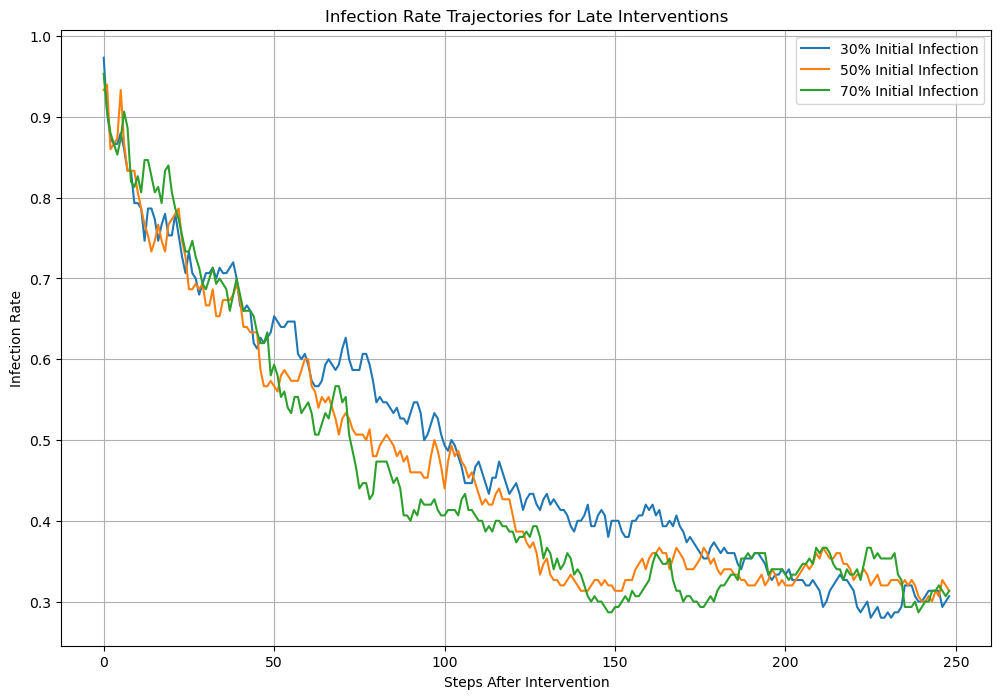


Late Intervention Results:
------------------------------------------------------------
Initial Rate    | Steps to 50%    | Final Rate     
------------------------------------------------------------
30%           | N/A             | 30.7%
50%           | N/A             | 31.3%
70%           |             132 | 31.3%


{0.3: {'infection_trajectory': [0.9733333333333334,
   0.9066666666666666,
   0.8733333333333333,
   0.8666666666666667,
   0.8666666666666667,
   0.88,
   0.86,
   0.8333333333333334,
   0.8333333333333334,
   0.7933333333333333,
   0.7933333333333333,
   0.7866666666666666,
   0.7466666666666667,
   0.7866666666666666,
   0.7866666666666666,
   0.7733333333333333,
   0.7466666666666667,
   0.7666666666666667,
   0.78,
   0.7533333333333333,
   0.7533333333333333,
   0.78,
   0.7533333333333333,
   0.7266666666666667,
   0.7066666666666667,
   0.7333333333333333,
   0.7066666666666667,
   0.7,
   0.68,
   0.6933333333333334,
   0.7066666666666667,
   0.7066666666666667,
   0.7133333333333334,
   0.7,
   0.7133333333333334,
   0.7066666666666667,
   0.7066666666666667,
   0.7133333333333334,
   0.72,
   0.7,
   0.6666666666666666,
   0.66,
   0.6666666666666666,
   0.66,
   0.62,
   0.6133333333333333,
   0.6266666666666667,
   0.62,
   0.6266666666666667,
   0.6333333333333333,
   0.6

In [ ]:
train_env_config = NetworkEnvironmentConfig(
    network_type = "erdos_renyi", 
    nx_n = N_NODES,
    nx_m = 3,
    nx_p = 0.2,
    num_nodes = N_NODES, 
    num_features = FeatureRegistry.get_feature_count(),
    infection_probability = 1, 
    recovery_probability = 0.1, 
    max_steps = MAX_STEPS, 
    max_action_radius = 0
)

analyze_late_intervention(algo,train_env_config)

Loading checkpoint: Checkpoint(filesystem=local, path=/Users/UM/ray_results/PPO_2025-04-27_01-23-23/PPO_network_spread_bd7e5_00000_0_2025-04-27_01-23-23/checkpoint_000007)


/opt/anaconda3/envs/RLEnv/lib/python3.8/site-packages/ray/rllib/algorithms/algorithm.py:500: RayDeprecationWarning: This API is deprecated and may be removed in future Ray releases. You could suppress this warning by setting env variable PYTHONWARNINGS="ignore::DeprecationWarning"
`UnifiedLogger` will be removed in Ray 2.7.
  return UnifiedLogger(config, logdir, loggers=None)
/opt/anaconda3/envs/RLEnv/lib/python3.8/site-packages/ray/tune/logger/unified.py:53: RayDeprecationWarning: This API is deprecated and may be removed in future Ray releases. You could suppress this warning by setting env variable PYTHONWARNINGS="ignore::DeprecationWarning"
The `JsonLogger interface is deprecated in favor of the `ray.tune.json.JsonLoggerCallback` interface and will be removed in Ray 2.7.
  self._loggers.append(cls(self.config, self.logdir, self.trial))
/opt/anaconda3/envs/RLEnv/lib/python3.8/site-packages/ray/tune/logger/unified.py:53: RayDeprecationWarning: This API is deprecated and may be remove


--- Episode 1/5 ---
Network has 50 nodes and 466 edges
Initially infected node: 35
Step 0: 1 infected, 49 susceptible
Action Dict: {'agent_a': 2, 'agent_b': 7}
Step 1: 2 infected, 48 susceptible
  Rewards - Agent A: 0.88, Agent B: 1.92
Action Dict: {'agent_a': 5, 'agent_b': 21}
Action Dict: {'agent_a': 36, 'agent_b': 26}
Action Dict: {'agent_a': 35, 'agent_b': 32}
Action Dict: {'agent_a': 26, 'agent_b': 5}
Action Dict: {'agent_a': 49, 'agent_b': 34}
Action Dict: {'agent_a': 23, 'agent_b': 41}
Action Dict: {'agent_a': 37, 'agent_b': 2}
Action Dict: {'agent_a': 38, 'agent_b': 2}
Action Dict: {'agent_a': 0, 'agent_b': 41}
Step 10: 45 infected, 5 susceptible
  Rewards - Agent A: 2.08, Agent B: 0.20


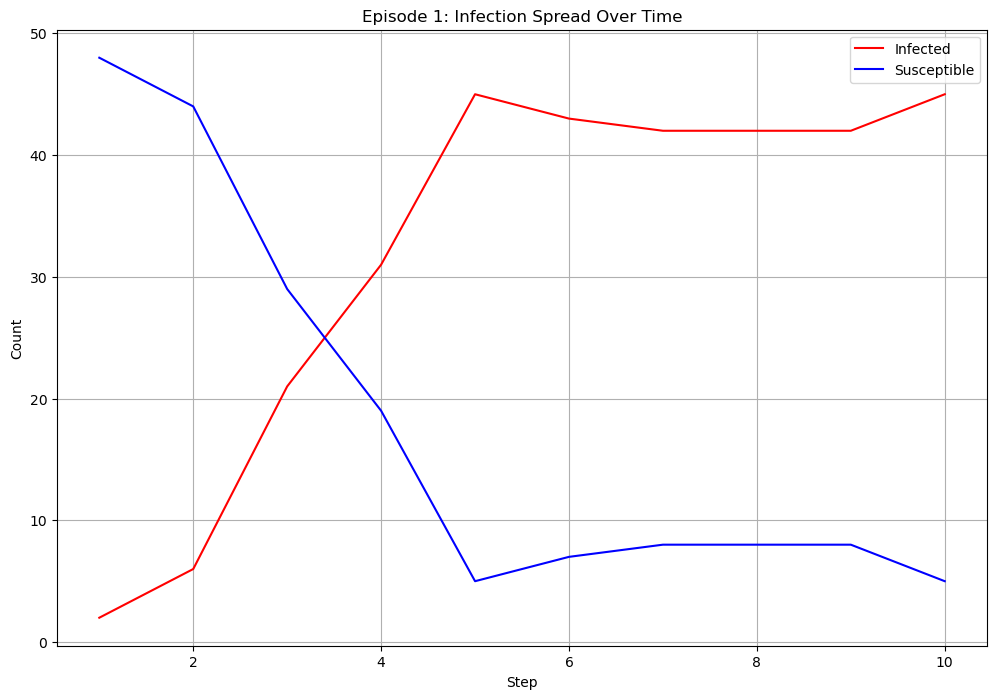

Action Dict: {'agent_a': 46, 'agent_b': 32}
Action Dict: {'agent_a': 7, 'agent_b': 49}
Action Dict: {'agent_a': 3, 'agent_b': 0}
Action Dict: {'agent_a': 18, 'agent_b': 21}
Action Dict: {'agent_a': 6, 'agent_b': 4}
Action Dict: {'agent_a': 35, 'agent_b': 10}
Action Dict: {'agent_a': 35, 'agent_b': 27}
Action Dict: {'agent_a': 11, 'agent_b': 2}
Action Dict: {'agent_a': 14, 'agent_b': 42}
Action Dict: {'agent_a': 30, 'agent_b': 2}
Step 20: 45 infected, 5 susceptible
  Rewards - Agent A: 1.72, Agent B: 0.20


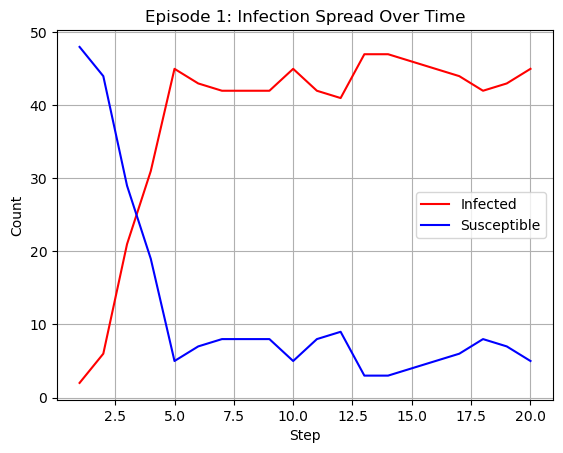

Action Dict: {'agent_a': 37, 'agent_b': 27}
Action Dict: {'agent_a': 5, 'agent_b': 29}
Action Dict: {'agent_a': 49, 'agent_b': 14}
Action Dict: {'agent_a': 37, 'agent_b': 13}
Action Dict: {'agent_a': 38, 'agent_b': 12}
Action Dict: {'agent_a': 21, 'agent_b': 14}
Action Dict: {'agent_a': 28, 'agent_b': 30}
Action Dict: {'agent_a': 39, 'agent_b': 41}
Action Dict: {'agent_a': 48, 'agent_b': 12}
Action Dict: {'agent_a': 5, 'agent_b': 0}
Step 30: 45 infected, 5 susceptible
  Rewards - Agent A: 0.88, Agent B: 0.20


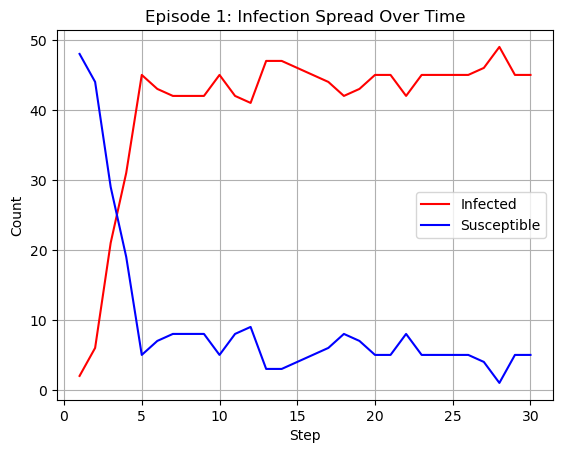

Action Dict: {'agent_a': 31, 'agent_b': 8}
Action Dict: {'agent_a': 25, 'agent_b': 9}
Action Dict: {'agent_a': 29, 'agent_b': 35}
Action Dict: {'agent_a': 20, 'agent_b': 4}
Action Dict: {'agent_a': 31, 'agent_b': 49}
Action Dict: {'agent_a': 5, 'agent_b': 41}
Action Dict: {'agent_a': 37, 'agent_b': 10}
Action Dict: {'agent_a': 15, 'agent_b': 37}
Action Dict: {'agent_a': 38, 'agent_b': 6}
Action Dict: {'agent_a': 26, 'agent_b': 41}
Step 40: 42 infected, 8 susceptible
  Rewards - Agent A: -0.49, Agent B: 0.32


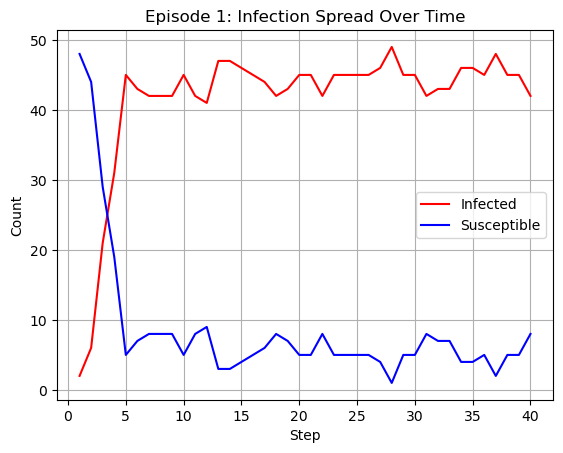

Action Dict: {'agent_a': 43, 'agent_b': 40}
Action Dict: {'agent_a': 3, 'agent_b': 14}
Action Dict: {'agent_a': 28, 'agent_b': 29}
Action Dict: {'agent_a': 22, 'agent_b': 33}
Action Dict: {'agent_a': 35, 'agent_b': 21}
Action Dict: {'agent_a': 18, 'agent_b': 37}
Action Dict: {'agent_a': 13, 'agent_b': 44}
Action Dict: {'agent_a': 21, 'agent_b': 41}
Action Dict: {'agent_a': 43, 'agent_b': 11}
Action Dict: {'agent_a': 6, 'agent_b': 6}
Step 50: 44 infected, 6 susceptible
  Rewards - Agent A: 1.65, Agent B: 0.24


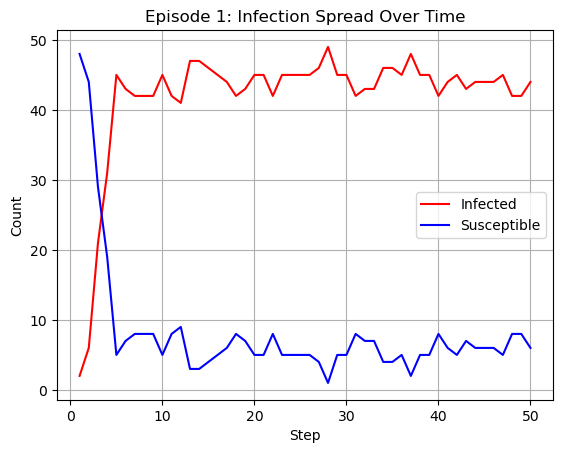

Action Dict: {'agent_a': 35, 'agent_b': 27}
Action Dict: {'agent_a': 18, 'agent_b': 43}
Action Dict: {'agent_a': 38, 'agent_b': 13}
Action Dict: {'agent_a': 5, 'agent_b': 49}
Action Dict: {'agent_a': 26, 'agent_b': 37}
Action Dict: {'agent_a': 45, 'agent_b': 6}
Action Dict: {'agent_a': 20, 'agent_b': 32}
Action Dict: {'agent_a': 15, 'agent_b': 5}
Action Dict: {'agent_a': 20, 'agent_b': 3}
Action Dict: {'agent_a': 38, 'agent_b': 41}
Step 60: 46 infected, 4 susceptible
  Rewards - Agent A: 1.32, Agent B: 0.16


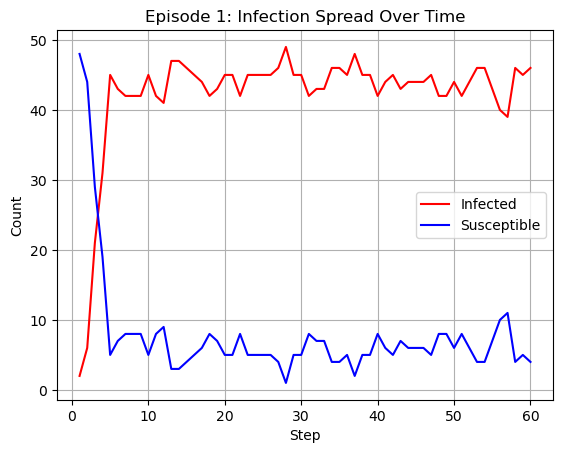

Action Dict: {'agent_a': 33, 'agent_b': 18}
Action Dict: {'agent_a': 37, 'agent_b': 39}
Action Dict: {'agent_a': 5, 'agent_b': 40}
Action Dict: {'agent_a': 22, 'agent_b': 10}
Action Dict: {'agent_a': 0, 'agent_b': 2}
Action Dict: {'agent_a': 46, 'agent_b': 5}
Action Dict: {'agent_a': 18, 'agent_b': 3}
Action Dict: {'agent_a': 20, 'agent_b': 39}
Action Dict: {'agent_a': 38, 'agent_b': 23}
Action Dict: {'agent_a': 46, 'agent_b': 2}
Step 70: 42 infected, 8 susceptible
  Rewards - Agent A: 1.54, Agent B: 0.32


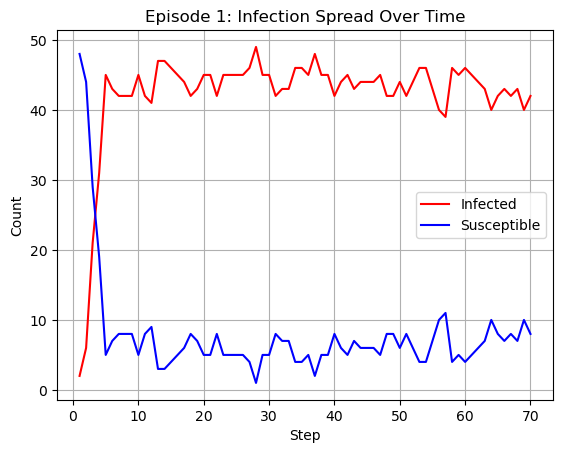

Action Dict: {'agent_a': 18, 'agent_b': 29}
Action Dict: {'agent_a': 0, 'agent_b': 0}
Action Dict: {'agent_a': 21, 'agent_b': 25}
Action Dict: {'agent_a': 46, 'agent_b': 4}
Action Dict: {'agent_a': 37, 'agent_b': 16}
Action Dict: {'agent_a': 18, 'agent_b': 30}
Action Dict: {'agent_a': 38, 'agent_b': 28}
Action Dict: {'agent_a': 8, 'agent_b': 41}
Action Dict: {'agent_a': 25, 'agent_b': 6}
Action Dict: {'agent_a': 2, 'agent_b': 32}
Step 80: 44 infected, 6 susceptible
  Rewards - Agent A: 0.81, Agent B: 0.24


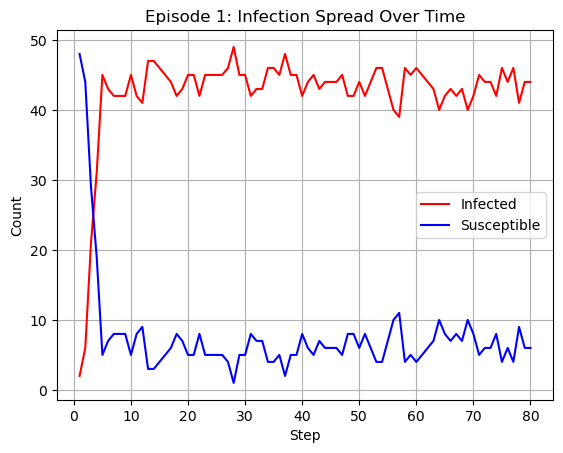

Action Dict: {'agent_a': 38, 'agent_b': 47}
Action Dict: {'agent_a': 20, 'agent_b': 5}
Action Dict: {'agent_a': 20, 'agent_b': 8}
Action Dict: {'agent_a': 45, 'agent_b': 43}
Action Dict: {'agent_a': 9, 'agent_b': 49}
Action Dict: {'agent_a': 6, 'agent_b': 13}
Action Dict: {'agent_a': 26, 'agent_b': 49}
Action Dict: {'agent_a': 14, 'agent_b': 49}
Action Dict: {'agent_a': 11, 'agent_b': 4}
Action Dict: {'agent_a': 5, 'agent_b': 49}
Step 90: 43 infected, 7 susceptible
  Rewards - Agent A: 0.39, Agent B: 0.28


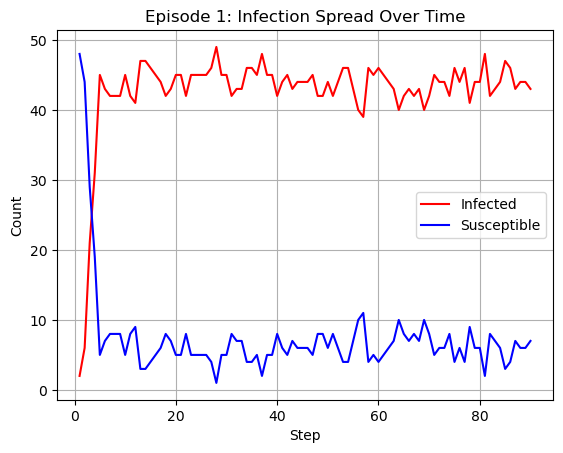

Action Dict: {'agent_a': 6, 'agent_b': 39}
Action Dict: {'agent_a': 25, 'agent_b': 49}
Action Dict: {'agent_a': 46, 'agent_b': 29}
Action Dict: {'agent_a': 38, 'agent_b': 6}
Action Dict: {'agent_a': 11, 'agent_b': 44}
Action Dict: {'agent_a': 11, 'agent_b': 44}
Action Dict: {'agent_a': 49, 'agent_b': 5}
Action Dict: {'agent_a': 14, 'agent_b': 49}
Action Dict: {'agent_a': 46, 'agent_b': 49}
Action Dict: {'agent_a': 5, 'agent_b': 49}
Step 100: 42 infected, 8 susceptible
  Rewards - Agent A: -0.80, Agent B: 0.32


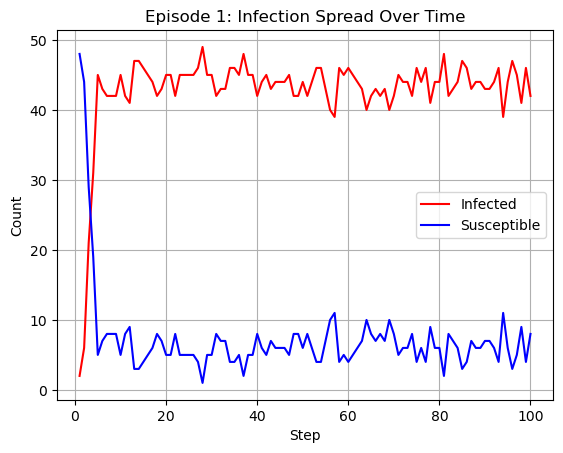


Episode ended at step 100
Maximum steps reached

--- Episode 2/5 ---
Network has 50 nodes and 466 edges
Initially infected node: 11
Step 0: 1 infected, 49 susceptible
Action Dict: {'agent_a': 32, 'agent_b': 7}
Step 1: 6 infected, 44 susceptible
  Rewards - Agent A: -14.84, Agent B: 1.76
Action Dict: {'agent_a': 11, 'agent_b': 32}
Action Dict: {'agent_a': 27, 'agent_b': 43}
Action Dict: {'agent_a': 41, 'agent_b': 0}
Action Dict: {'agent_a': 25, 'agent_b': 48}
Action Dict: {'agent_a': 37, 'agent_b': 18}
Action Dict: {'agent_a': 0, 'agent_b': 41}
Action Dict: {'agent_a': 6, 'agent_b': 16}
Action Dict: {'agent_a': 0, 'agent_b': 49}
Action Dict: {'agent_a': 36, 'agent_b': 32}
Step 10: 38 infected, 12 susceptible
  Rewards - Agent A: -3.40, Agent B: 0.48


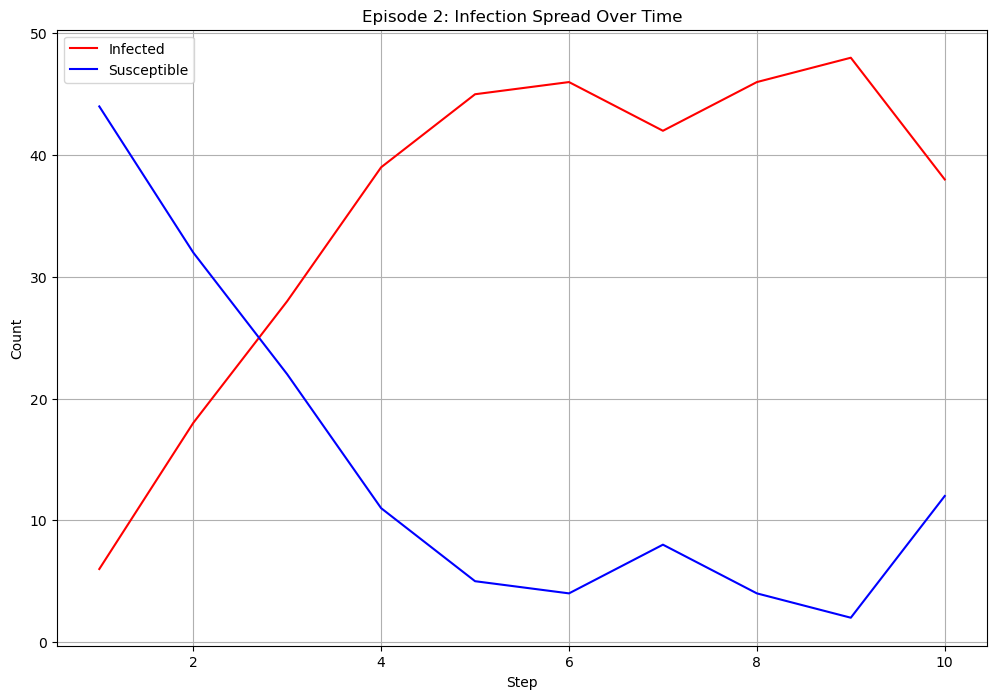

Action Dict: {'agent_a': 38, 'agent_b': 10}
Action Dict: {'agent_a': 35, 'agent_b': 17}
Action Dict: {'agent_a': 25, 'agent_b': 5}
Action Dict: {'agent_a': 41, 'agent_b': 39}
Action Dict: {'agent_a': 35, 'agent_b': 35}
Action Dict: {'agent_a': 26, 'agent_b': 10}
Action Dict: {'agent_a': 11, 'agent_b': 21}
Action Dict: {'agent_a': 20, 'agent_b': 16}
Action Dict: {'agent_a': 39, 'agent_b': 12}
Action Dict: {'agent_a': 5, 'agent_b': 0}
Step 20: 48 infected, 2 susceptible
  Rewards - Agent A: 4.19, Agent B: 0.08


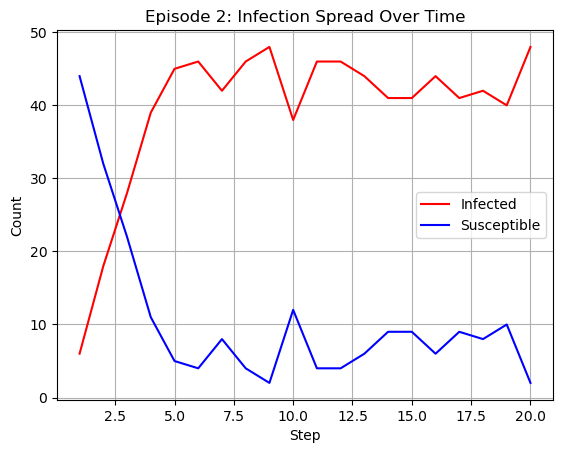

Action Dict: {'agent_a': 6, 'agent_b': 18}
Action Dict: {'agent_a': 23, 'agent_b': 41}
Action Dict: {'agent_a': 37, 'agent_b': 15}
Action Dict: {'agent_a': 29, 'agent_b': 44}
Action Dict: {'agent_a': 5, 'agent_b': 6}
Action Dict: {'agent_a': 4, 'agent_b': 49}
Action Dict: {'agent_a': 38, 'agent_b': 41}
Action Dict: {'agent_a': 37, 'agent_b': 4}
Action Dict: {'agent_a': 39, 'agent_b': 3}
Action Dict: {'agent_a': 38, 'agent_b': 4}
Step 30: 41 infected, 9 susceptible
  Rewards - Agent A: -1.33, Agent B: 0.36


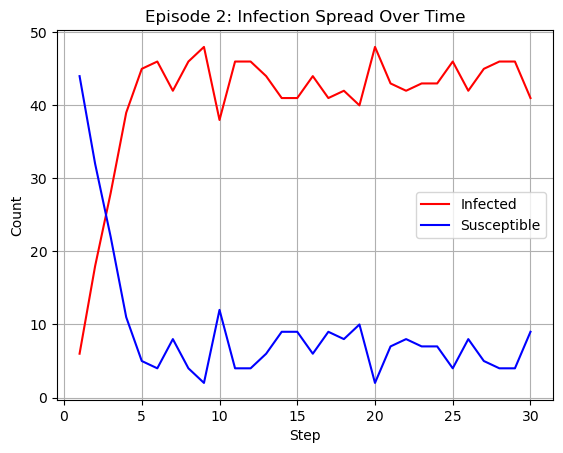

Action Dict: {'agent_a': 35, 'agent_b': 41}
Action Dict: {'agent_a': 38, 'agent_b': 3}
Action Dict: {'agent_a': 38, 'agent_b': 40}
Action Dict: {'agent_a': 38, 'agent_b': 14}
Action Dict: {'agent_a': 28, 'agent_b': 16}
Action Dict: {'agent_a': 8, 'agent_b': 21}
Action Dict: {'agent_a': 37, 'agent_b': 8}
Action Dict: {'agent_a': 49, 'agent_b': 5}
Action Dict: {'agent_a': 25, 'agent_b': 49}
Action Dict: {'agent_a': 37, 'agent_b': 28}
Step 40: 43 infected, 7 susceptible
  Rewards - Agent A: 0.42, Agent B: 0.28


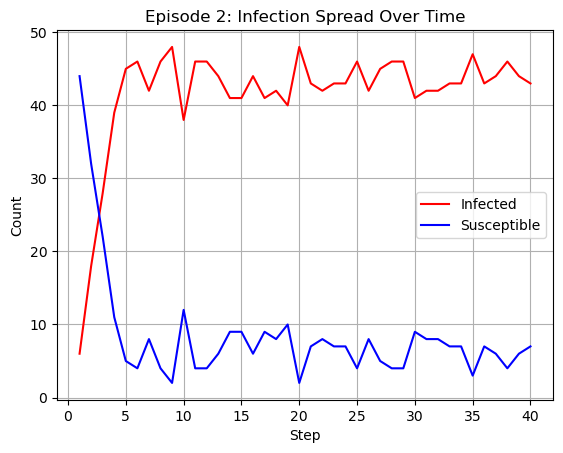

Action Dict: {'agent_a': 38, 'agent_b': 9}
Action Dict: {'agent_a': 3, 'agent_b': 13}
Action Dict: {'agent_a': 36, 'agent_b': 21}
Action Dict: {'agent_a': 41, 'agent_b': 49}
Action Dict: {'agent_a': 49, 'agent_b': 15}
Action Dict: {'agent_a': 25, 'agent_b': 5}
Action Dict: {'agent_a': 3, 'agent_b': 18}
Action Dict: {'agent_a': 26, 'agent_b': 10}
Action Dict: {'agent_a': 9, 'agent_b': 44}
Action Dict: {'agent_a': 26, 'agent_b': 44}
Step 50: 49 infected, 1 susceptible
  Rewards - Agent A: 5.02, Agent B: 0.04


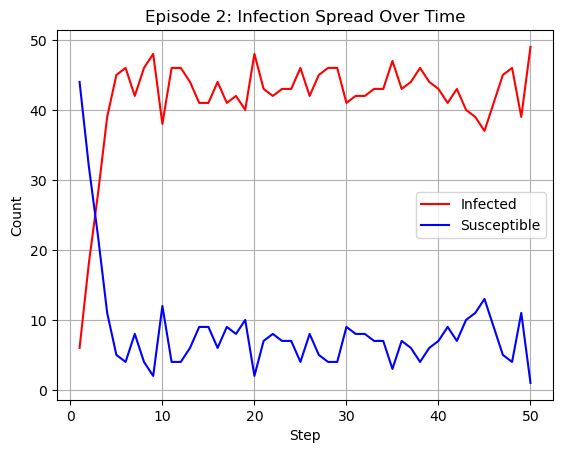

Action Dict: {'agent_a': 49, 'agent_b': 10}
Action Dict: {'agent_a': 43, 'agent_b': 26}
Action Dict: {'agent_a': 38, 'agent_b': 31}
Action Dict: {'agent_a': 39, 'agent_b': 18}
Action Dict: {'agent_a': 11, 'agent_b': 37}
Action Dict: {'agent_a': 5, 'agent_b': 16}
Action Dict: {'agent_a': 38, 'agent_b': 5}
Action Dict: {'agent_a': 38, 'agent_b': 44}
Action Dict: {'agent_a': 11, 'agent_b': 49}
Action Dict: {'agent_a': 41, 'agent_b': 33}
Step 60: 46 infected, 4 susceptible
  Rewards - Agent A: 2.11, Agent B: 0.16


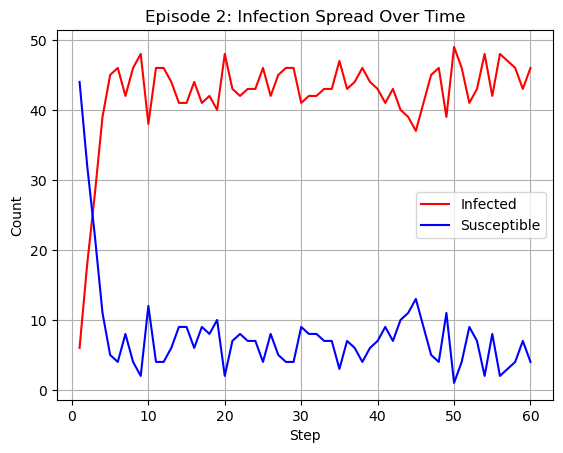

Action Dict: {'agent_a': 38, 'agent_b': 41}
Action Dict: {'agent_a': 33, 'agent_b': 0}
Action Dict: {'agent_a': 20, 'agent_b': 13}
Action Dict: {'agent_a': 9, 'agent_b': 49}
Action Dict: {'agent_a': 36, 'agent_b': 23}
Action Dict: {'agent_a': 23, 'agent_b': 21}
Action Dict: {'agent_a': 0, 'agent_b': 33}
Action Dict: {'agent_a': 38, 'agent_b': 26}
Action Dict: {'agent_a': 5, 'agent_b': 10}
Action Dict: {'agent_a': 46, 'agent_b': 9}
Step 70: 47 infected, 3 susceptible
  Rewards - Agent A: 2.14, Agent B: 0.12


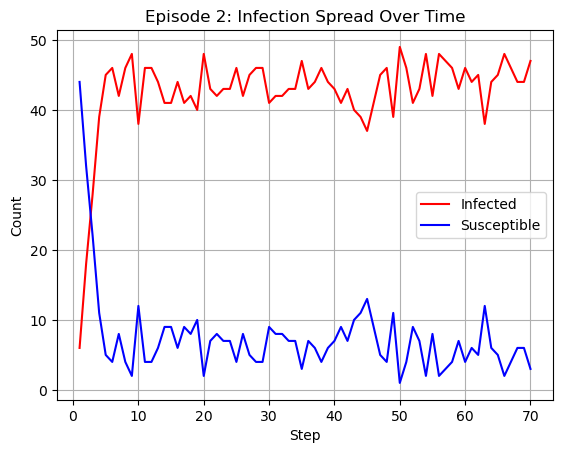

Action Dict: {'agent_a': 49, 'agent_b': 13}
Action Dict: {'agent_a': 25, 'agent_b': 49}
Action Dict: {'agent_a': 10, 'agent_b': 37}
Action Dict: {'agent_a': 28, 'agent_b': 49}
Action Dict: {'agent_a': 8, 'agent_b': 21}
Action Dict: {'agent_a': 39, 'agent_b': 37}
Action Dict: {'agent_a': 5, 'agent_b': 49}
Action Dict: {'agent_a': 48, 'agent_b': 3}
Action Dict: {'agent_a': 38, 'agent_b': 29}
Action Dict: {'agent_a': 22, 'agent_b': 3}
Step 80: 49 infected, 1 susceptible
  Rewards - Agent A: 3.42, Agent B: 0.04


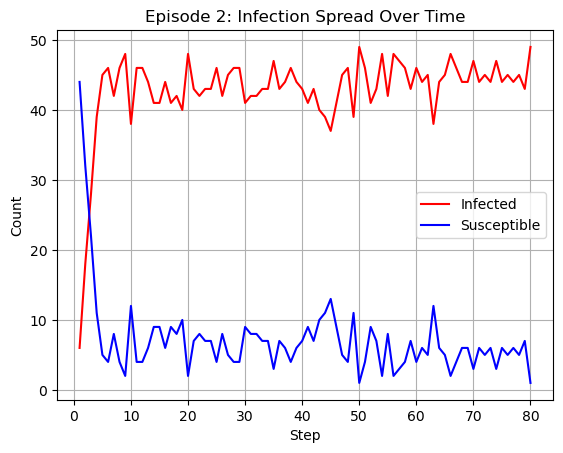

Action Dict: {'agent_a': 11, 'agent_b': 41}
Action Dict: {'agent_a': 36, 'agent_b': 34}
Action Dict: {'agent_a': 4, 'agent_b': 35}
Action Dict: {'agent_a': 39, 'agent_b': 2}
Action Dict: {'agent_a': 6, 'agent_b': 13}
Action Dict: {'agent_a': 37, 'agent_b': 39}
Action Dict: {'agent_a': 5, 'agent_b': 13}
Action Dict: {'agent_a': 46, 'agent_b': 41}
Action Dict: {'agent_a': 35, 'agent_b': 6}
Action Dict: {'agent_a': 38, 'agent_b': 32}
Step 90: 46 infected, 4 susceptible
  Rewards - Agent A: 1.29, Agent B: 0.16


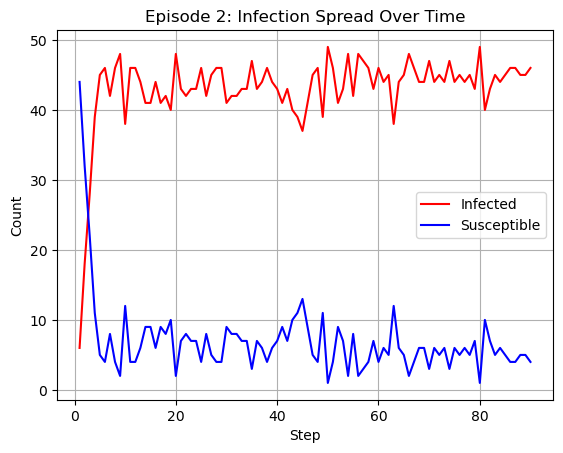

Action Dict: {'agent_a': 43, 'agent_b': 39}
Action Dict: {'agent_a': 18, 'agent_b': 23}
Action Dict: {'agent_a': 38, 'agent_b': 27}
Action Dict: {'agent_a': 37, 'agent_b': 20}
Action Dict: {'agent_a': 5, 'agent_b': 4}
Action Dict: {'agent_a': 25, 'agent_b': 41}
Action Dict: {'agent_a': 39, 'agent_b': 28}
Action Dict: {'agent_a': 36, 'agent_b': 8}
Action Dict: {'agent_a': 14, 'agent_b': 21}
Action Dict: {'agent_a': 21, 'agent_b': 26}
Step 100: 45 infected, 5 susceptible
  Rewards - Agent A: 1.66, Agent B: 0.20


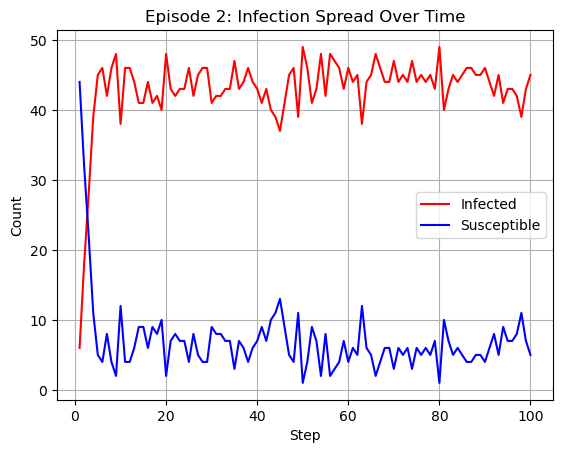


Episode ended at step 100
Maximum steps reached

--- Episode 3/5 ---
Network has 50 nodes and 466 edges
Initially infected node: 11
Step 0: 1 infected, 49 susceptible
Action Dict: {'agent_a': 15, 'agent_b': 7}
Falling back to degree centrality: (PowerIterationFailedConvergence(...), 'power iteration failed to converge within 1000 iterations')
Step 1: 5 infected, 45 susceptible
  Rewards - Agent A: -16.22, Agent B: 1.80
Action Dict: {'agent_a': 36, 'agent_b': 44}
Action Dict: {'agent_a': 35, 'agent_b': 17}
Action Dict: {'agent_a': 14, 'agent_b': 2}
Action Dict: {'agent_a': 20, 'agent_b': 27}
Action Dict: {'agent_a': 15, 'agent_b': 21}
Action Dict: {'agent_a': 37, 'agent_b': 8}
Action Dict: {'agent_a': 15, 'agent_b': 12}
Action Dict: {'agent_a': 38, 'agent_b': 12}
Action Dict: {'agent_a': 36, 'agent_b': 18}
Step 10: 45 infected, 5 susceptible
  Rewards - Agent A: 1.67, Agent B: 0.20


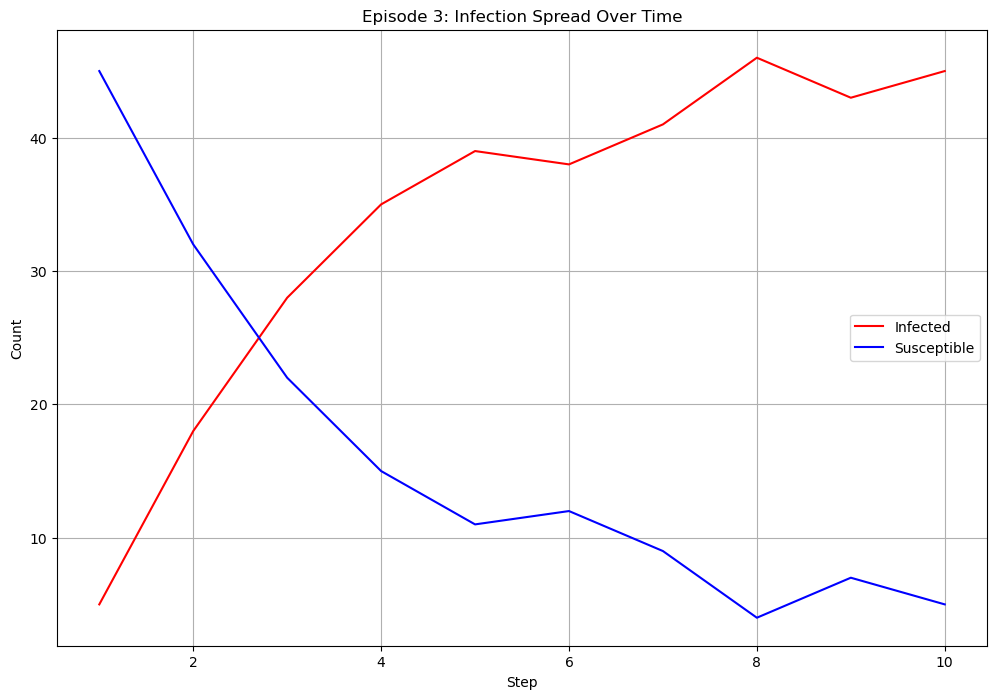

Action Dict: {'agent_a': 5, 'agent_b': 32}
Action Dict: {'agent_a': 46, 'agent_b': 5}
Action Dict: {'agent_a': 38, 'agent_b': 23}
Action Dict: {'agent_a': 14, 'agent_b': 6}
Action Dict: {'agent_a': 31, 'agent_b': 18}
Action Dict: {'agent_a': 22, 'agent_b': 48}
Action Dict: {'agent_a': 49, 'agent_b': 40}
Action Dict: {'agent_a': 11, 'agent_b': 26}

Episode ended at step 18
All nodes infected - Spreader (Agent A) wins!

--- Episode 4/5 ---
Network has 50 nodes and 466 edges
Initially infected node: 49
Step 0: 1 infected, 49 susceptible
Action Dict: {'agent_a': 49, 'agent_b': 7}
Step 1: 3 infected, 47 susceptible
  Rewards - Agent A: -18.68, Agent B: 1.88
Action Dict: {'agent_a': 36, 'agent_b': 34}
Action Dict: {'agent_a': 35, 'agent_b': 44}
Action Dict: {'agent_a': 0, 'agent_b': 27}
Action Dict: {'agent_a': 5, 'agent_b': 13}
Action Dict: {'agent_a': 20, 'agent_b': 42}
Action Dict: {'agent_a': 39, 'agent_b': 3}
Action Dict: {'agent_a': 46, 'agent_b': 27}
Action Dict: {'agent_a': 39, 'agen

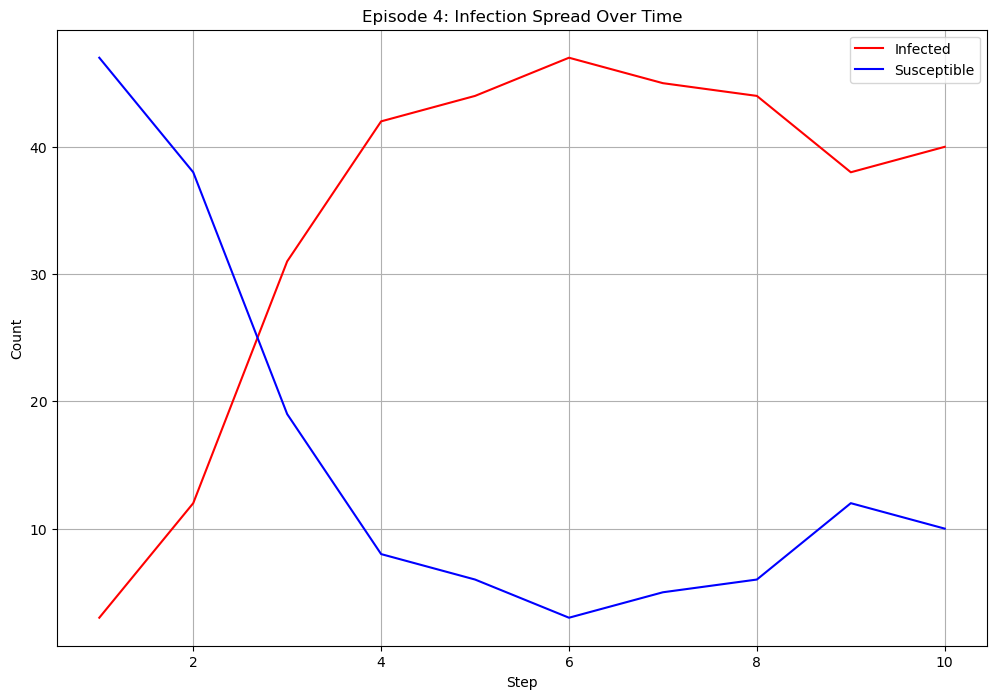

Action Dict: {'agent_a': 49, 'agent_b': 18}
Action Dict: {'agent_a': 41, 'agent_b': 8}
Action Dict: {'agent_a': 15, 'agent_b': 33}
Action Dict: {'agent_a': 26, 'agent_b': 49}
Action Dict: {'agent_a': 36, 'agent_b': 21}
Action Dict: {'agent_a': 0, 'agent_b': 41}
Action Dict: {'agent_a': 8, 'agent_b': 17}
Action Dict: {'agent_a': 0, 'agent_b': 6}
Action Dict: {'agent_a': 18, 'agent_b': 49}
Action Dict: {'agent_a': 0, 'agent_b': 49}
Step 20: 45 infected, 5 susceptible
  Rewards - Agent A: 0.85, Agent B: 0.20


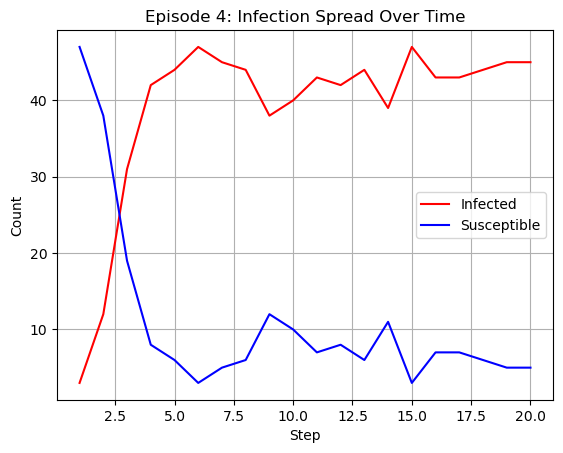

Action Dict: {'agent_a': 25, 'agent_b': 14}
Action Dict: {'agent_a': 37, 'agent_b': 49}
Action Dict: {'agent_a': 39, 'agent_b': 20}
Action Dict: {'agent_a': 35, 'agent_b': 5}
Action Dict: {'agent_a': 46, 'agent_b': 49}
Action Dict: {'agent_a': 11, 'agent_b': 21}
Action Dict: {'agent_a': 3, 'agent_b': 31}
Action Dict: {'agent_a': 5, 'agent_b': 20}
Action Dict: {'agent_a': 5, 'agent_b': 39}
Action Dict: {'agent_a': 10, 'agent_b': 49}
Step 30: 48 infected, 2 susceptible
  Rewards - Agent A: 2.97, Agent B: 0.08


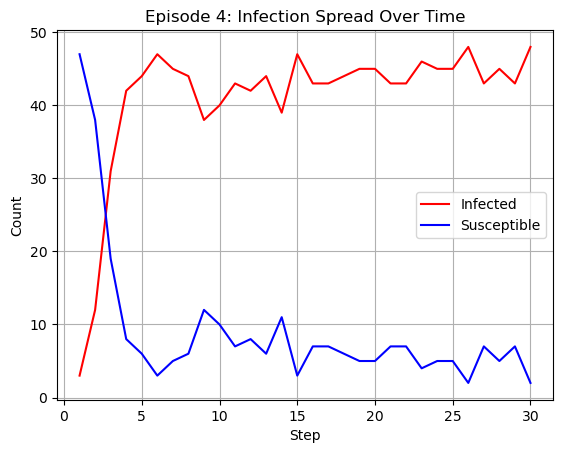

Action Dict: {'agent_a': 5, 'agent_b': 37}
Action Dict: {'agent_a': 31, 'agent_b': 0}
Action Dict: {'agent_a': 35, 'agent_b': 29}
Action Dict: {'agent_a': 38, 'agent_b': 16}
Action Dict: {'agent_a': 21, 'agent_b': 32}
Action Dict: {'agent_a': 25, 'agent_b': 8}
Action Dict: {'agent_a': 3, 'agent_b': 29}
Action Dict: {'agent_a': 18, 'agent_b': 49}
Action Dict: {'agent_a': 35, 'agent_b': 49}
Action Dict: {'agent_a': 11, 'agent_b': 27}
Step 40: 46 infected, 4 susceptible
  Rewards - Agent A: 1.72, Agent B: 0.16


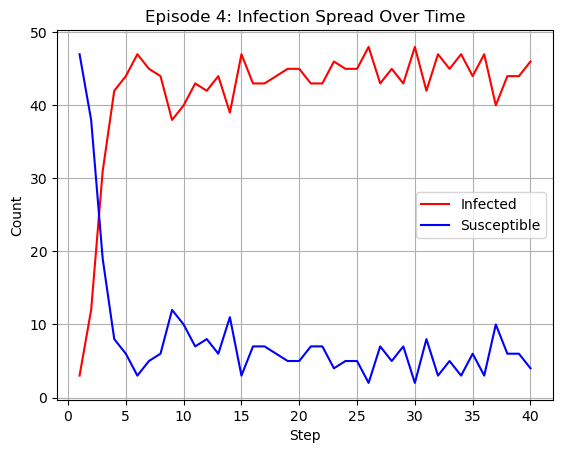

Action Dict: {'agent_a': 41, 'agent_b': 19}
Action Dict: {'agent_a': 39, 'agent_b': 21}
Action Dict: {'agent_a': 26, 'agent_b': 8}
Action Dict: {'agent_a': 5, 'agent_b': 9}
Action Dict: {'agent_a': 37, 'agent_b': 13}
Action Dict: {'agent_a': 11, 'agent_b': 23}
Action Dict: {'agent_a': 38, 'agent_b': 18}
Action Dict: {'agent_a': 5, 'agent_b': 7}
Action Dict: {'agent_a': 11, 'agent_b': 48}
Action Dict: {'agent_a': 38, 'agent_b': 34}
Step 50: 46 infected, 4 susceptible
  Rewards - Agent A: 0.10, Agent B: 0.16


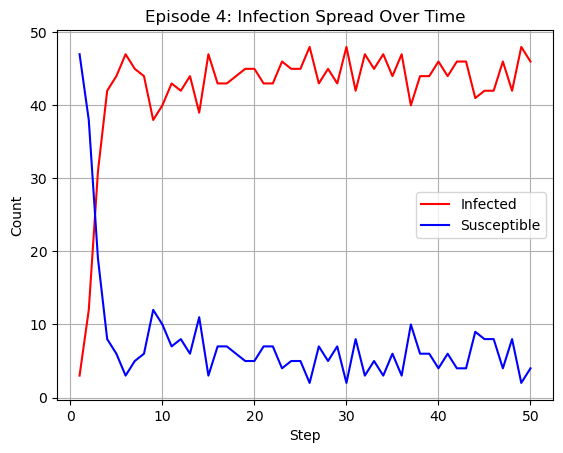

Action Dict: {'agent_a': 0, 'agent_b': 49}
Action Dict: {'agent_a': 38, 'agent_b': 0}
Action Dict: {'agent_a': 26, 'agent_b': 44}
Action Dict: {'agent_a': 37, 'agent_b': 44}
Action Dict: {'agent_a': 44, 'agent_b': 2}
Action Dict: {'agent_a': 5, 'agent_b': 6}
Action Dict: {'agent_a': 38, 'agent_b': 41}
Action Dict: {'agent_a': 14, 'agent_b': 41}
Action Dict: {'agent_a': 18, 'agent_b': 49}
Action Dict: {'agent_a': 22, 'agent_b': 41}
Step 60: 48 infected, 2 susceptible
  Rewards - Agent A: 1.80, Agent B: 0.08


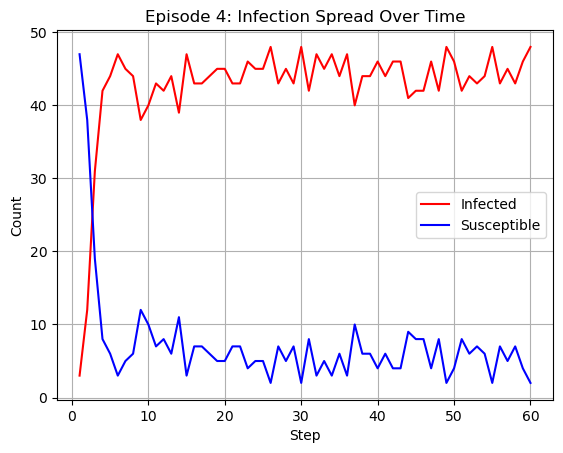

Action Dict: {'agent_a': 25, 'agent_b': 43}
Action Dict: {'agent_a': 41, 'agent_b': 21}
Action Dict: {'agent_a': 49, 'agent_b': 23}
Action Dict: {'agent_a': 38, 'agent_b': 44}
Action Dict: {'agent_a': 43, 'agent_b': 28}
Action Dict: {'agent_a': 5, 'agent_b': 32}
Action Dict: {'agent_a': 38, 'agent_b': 5}
Action Dict: {'agent_a': 26, 'agent_b': 5}
Action Dict: {'agent_a': 18, 'agent_b': 16}
Action Dict: {'agent_a': 45, 'agent_b': 27}
Step 70: 44 infected, 6 susceptible
  Rewards - Agent A: 0.49, Agent B: 0.24


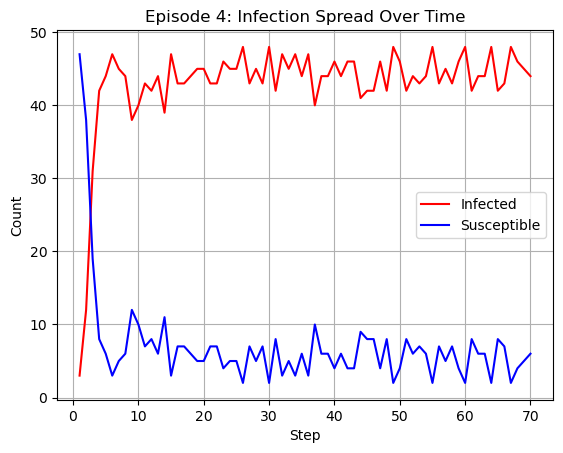

Action Dict: {'agent_a': 22, 'agent_b': 24}
Action Dict: {'agent_a': 21, 'agent_b': 27}
Action Dict: {'agent_a': 15, 'agent_b': 5}
Action Dict: {'agent_a': 25, 'agent_b': 20}
Action Dict: {'agent_a': 38, 'agent_b': 26}
Action Dict: {'agent_a': 39, 'agent_b': 49}
Action Dict: {'agent_a': 22, 'agent_b': 48}
Action Dict: {'agent_a': 38, 'agent_b': 26}
Action Dict: {'agent_a': 38, 'agent_b': 48}
Action Dict: {'agent_a': 27, 'agent_b': 32}
Step 80: 48 infected, 2 susceptible
  Rewards - Agent A: 2.99, Agent B: 0.08


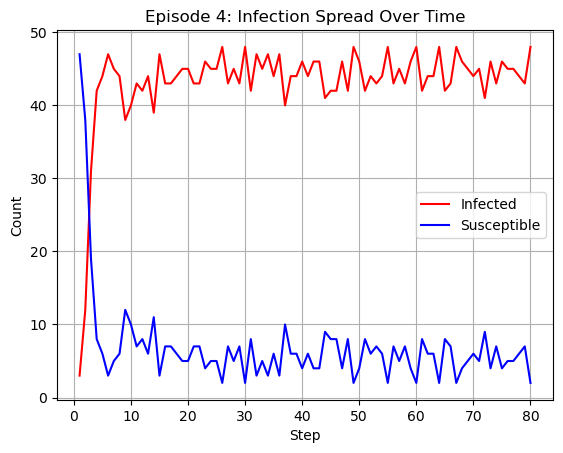

Action Dict: {'agent_a': 18, 'agent_b': 21}
Action Dict: {'agent_a': 11, 'agent_b': 41}
Action Dict: {'agent_a': 5, 'agent_b': 49}
Action Dict: {'agent_a': 14, 'agent_b': 41}
Action Dict: {'agent_a': 39, 'agent_b': 15}
Action Dict: {'agent_a': 37, 'agent_b': 26}
Action Dict: {'agent_a': 49, 'agent_b': 48}
Action Dict: {'agent_a': 21, 'agent_b': 36}
Action Dict: {'agent_a': 2, 'agent_b': 44}
Action Dict: {'agent_a': 26, 'agent_b': 41}
Step 90: 47 infected, 3 susceptible
  Rewards - Agent A: 1.78, Agent B: 0.12


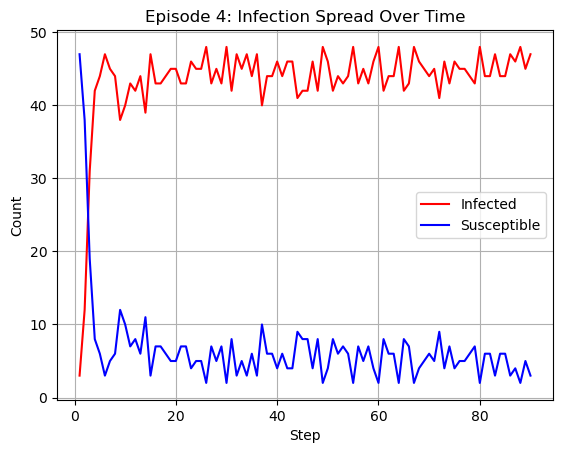

Action Dict: {'agent_a': 5, 'agent_b': 33}
Action Dict: {'agent_a': 13, 'agent_b': 6}
Action Dict: {'agent_a': 26, 'agent_b': 49}
Action Dict: {'agent_a': 21, 'agent_b': 0}
Action Dict: {'agent_a': 5, 'agent_b': 34}
Action Dict: {'agent_a': 5, 'agent_b': 32}
Action Dict: {'agent_a': 21, 'agent_b': 41}
Action Dict: {'agent_a': 20, 'agent_b': 9}
Action Dict: {'agent_a': 39, 'agent_b': 36}
Action Dict: {'agent_a': 14, 'agent_b': 41}
Step 100: 48 infected, 2 susceptible
  Rewards - Agent A: 2.20, Agent B: 0.08


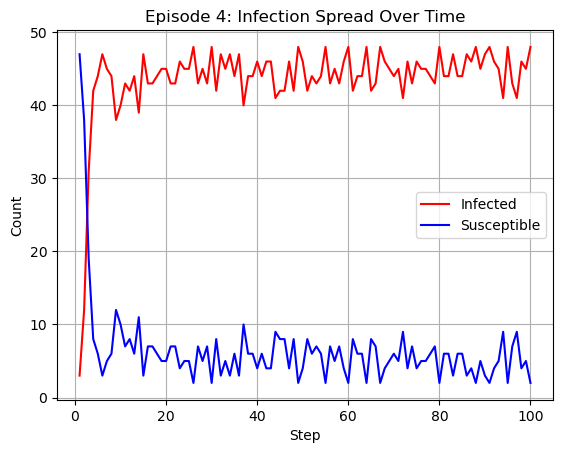


Episode ended at step 100
Maximum steps reached

--- Episode 5/5 ---
Network has 50 nodes and 466 edges
Initially infected node: 46
Step 0: 1 infected, 49 susceptible
Action Dict: {'agent_a': 3, 'agent_b': 7}
Step 1: 5 infected, 45 susceptible
  Rewards - Agent A: -17.00, Agent B: 1.80
Action Dict: {'agent_a': 46, 'agent_b': 10}
Action Dict: {'agent_a': 26, 'agent_b': 45}
Action Dict: {'agent_a': 13, 'agent_b': 6}
Action Dict: {'agent_a': 39, 'agent_b': 21}
Action Dict: {'agent_a': 20, 'agent_b': 6}
Action Dict: {'agent_a': 11, 'agent_b': 11}
Action Dict: {'agent_a': 6, 'agent_b': 49}
Action Dict: {'agent_a': 20, 'agent_b': 6}
Action Dict: {'agent_a': 4, 'agent_b': 4}
Step 10: 47 infected, 3 susceptible
  Rewards - Agent A: 1.36, Agent B: 0.12


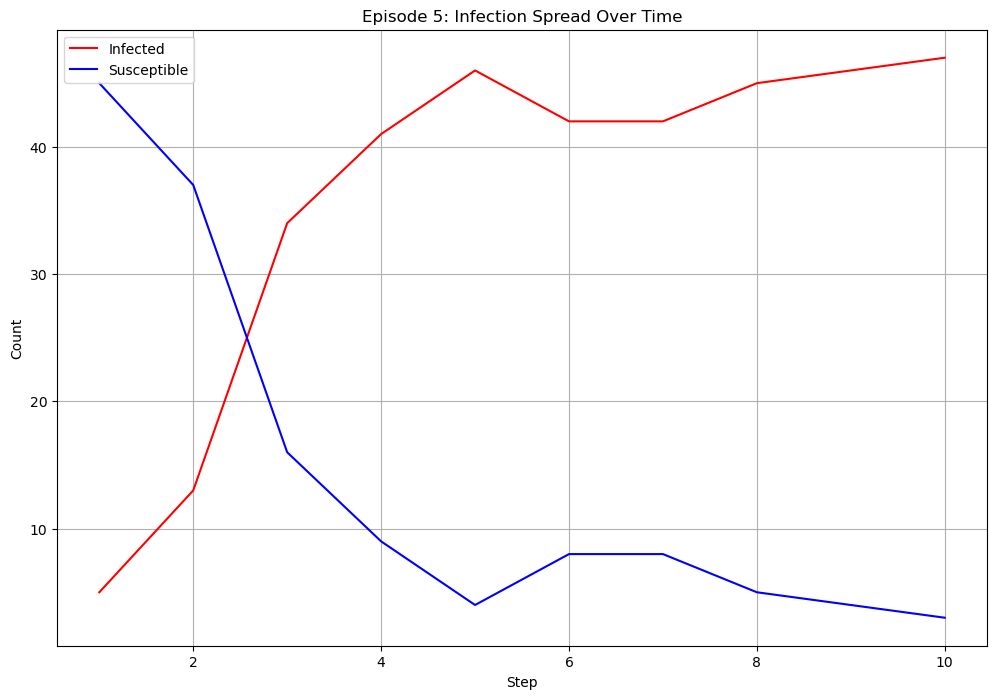

Action Dict: {'agent_a': 38, 'agent_b': 48}
Action Dict: {'agent_a': 46, 'agent_b': 16}
Action Dict: {'agent_a': 44, 'agent_b': 21}
Action Dict: {'agent_a': 13, 'agent_b': 29}
Action Dict: {'agent_a': 39, 'agent_b': 0}
Action Dict: {'agent_a': 49, 'agent_b': 26}
Action Dict: {'agent_a': 0, 'agent_b': 49}
Action Dict: {'agent_a': 36, 'agent_b': 39}
Action Dict: {'agent_a': 35, 'agent_b': 32}
Action Dict: {'agent_a': 9, 'agent_b': 17}
Step 20: 43 infected, 7 susceptible
  Rewards - Agent A: 0.47, Agent B: 0.28


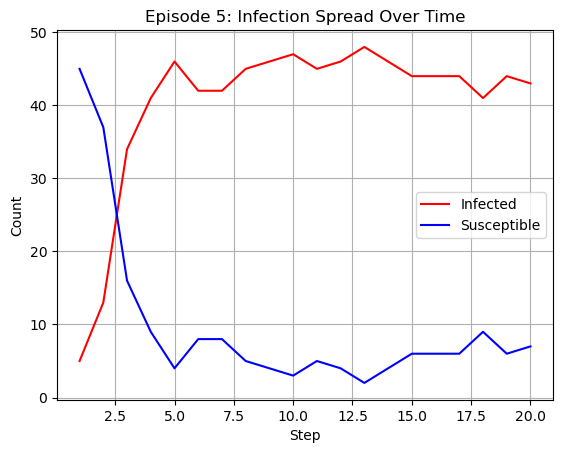

Action Dict: {'agent_a': 41, 'agent_b': 14}
Action Dict: {'agent_a': 11, 'agent_b': 25}
Action Dict: {'agent_a': 14, 'agent_b': 34}
Action Dict: {'agent_a': 2, 'agent_b': 14}
Action Dict: {'agent_a': 0, 'agent_b': 14}
Action Dict: {'agent_a': 39, 'agent_b': 16}
Action Dict: {'agent_a': 35, 'agent_b': 5}
Action Dict: {'agent_a': 36, 'agent_b': 43}
Action Dict: {'agent_a': 21, 'agent_b': 16}
Action Dict: {'agent_a': 20, 'agent_b': 18}
Step 30: 47 infected, 3 susceptible
  Rewards - Agent A: 2.92, Agent B: 0.12


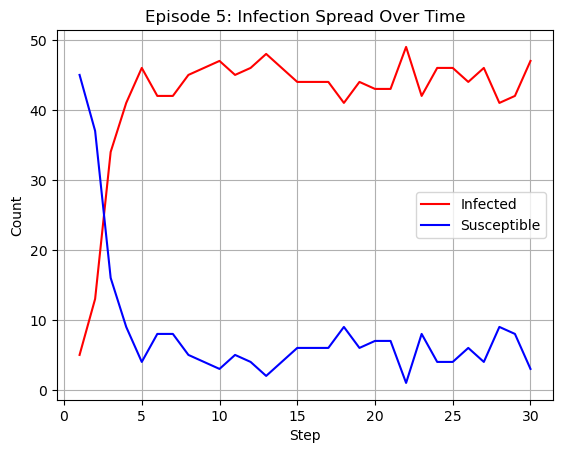

Action Dict: {'agent_a': 31, 'agent_b': 48}
Action Dict: {'agent_a': 5, 'agent_b': 23}
Action Dict: {'agent_a': 23, 'agent_b': 6}
Action Dict: {'agent_a': 49, 'agent_b': 14}
Action Dict: {'agent_a': 5, 'agent_b': 25}
Action Dict: {'agent_a': 46, 'agent_b': 42}
Action Dict: {'agent_a': 41, 'agent_b': 2}
Action Dict: {'agent_a': 34, 'agent_b': 11}
Action Dict: {'agent_a': 4, 'agent_b': 2}
Action Dict: {'agent_a': 5, 'agent_b': 6}
Step 40: 45 infected, 5 susceptible
  Rewards - Agent A: 1.70, Agent B: 0.20


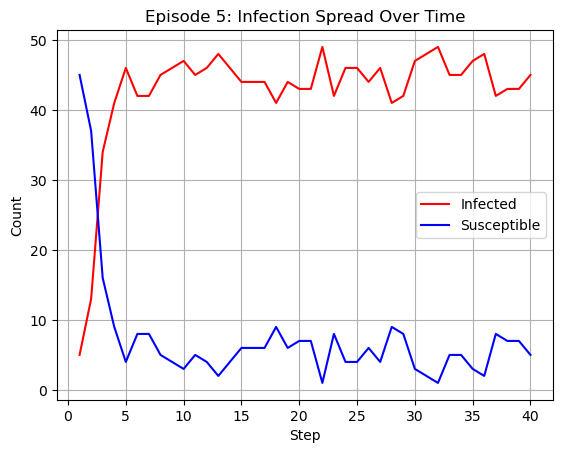

Action Dict: {'agent_a': 3, 'agent_b': 2}
Action Dict: {'agent_a': 26, 'agent_b': 48}
Action Dict: {'agent_a': 38, 'agent_b': 41}
Action Dict: {'agent_a': 2, 'agent_b': 42}
Action Dict: {'agent_a': 0, 'agent_b': 21}
Action Dict: {'agent_a': 18, 'agent_b': 13}
Action Dict: {'agent_a': 5, 'agent_b': 48}
Action Dict: {'agent_a': 38, 'agent_b': 13}
Action Dict: {'agent_a': 49, 'agent_b': 28}
Action Dict: {'agent_a': 21, 'agent_b': 25}
Step 50: 43 infected, 7 susceptible
  Rewards - Agent A: -0.44, Agent B: 0.28


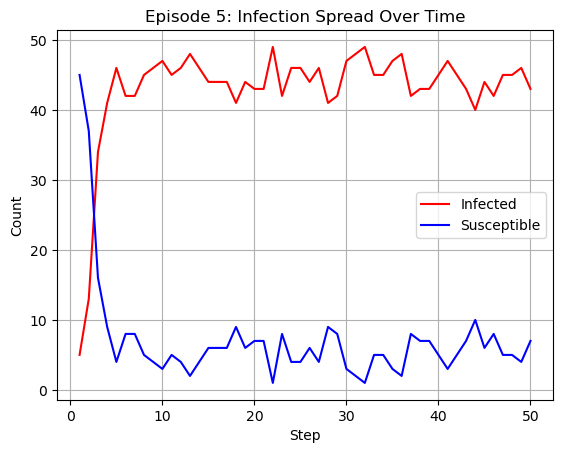

Action Dict: {'agent_a': 29, 'agent_b': 49}
Action Dict: {'agent_a': 29, 'agent_b': 37}
Action Dict: {'agent_a': 5, 'agent_b': 3}
Action Dict: {'agent_a': 27, 'agent_b': 26}
Action Dict: {'agent_a': 38, 'agent_b': 26}
Action Dict: {'agent_a': 38, 'agent_b': 5}
Action Dict: {'agent_a': 26, 'agent_b': 6}
Action Dict: {'agent_a': 13, 'agent_b': 13}
Action Dict: {'agent_a': 36, 'agent_b': 4}
Action Dict: {'agent_a': 28, 'agent_b': 14}
Step 60: 41 infected, 9 susceptible
  Rewards - Agent A: -0.84, Agent B: 0.36


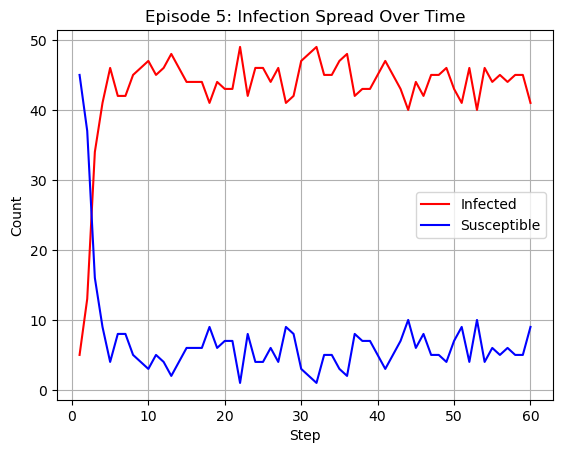

Action Dict: {'agent_a': 46, 'agent_b': 9}
Action Dict: {'agent_a': 22, 'agent_b': 10}
Action Dict: {'agent_a': 17, 'agent_b': 49}
Action Dict: {'agent_a': 11, 'agent_b': 6}
Action Dict: {'agent_a': 30, 'agent_b': 6}
Action Dict: {'agent_a': 6, 'agent_b': 21}
Action Dict: {'agent_a': 35, 'agent_b': 49}
Action Dict: {'agent_a': 21, 'agent_b': 44}
Action Dict: {'agent_a': 11, 'agent_b': 34}
Action Dict: {'agent_a': 46, 'agent_b': 21}
Step 70: 45 infected, 5 susceptible
  Rewards - Agent A: 0.88, Agent B: 0.20


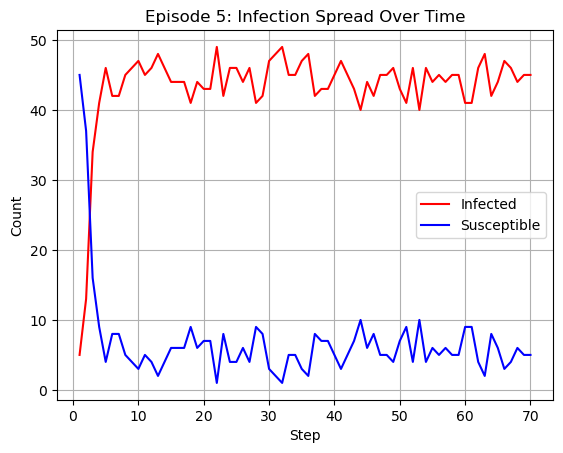

Action Dict: {'agent_a': 37, 'agent_b': 48}
Action Dict: {'agent_a': 28, 'agent_b': 29}
Action Dict: {'agent_a': 37, 'agent_b': 16}
Action Dict: {'agent_a': 20, 'agent_b': 45}
Action Dict: {'agent_a': 33, 'agent_b': 10}
Action Dict: {'agent_a': 35, 'agent_b': 44}
Action Dict: {'agent_a': 20, 'agent_b': 49}
Action Dict: {'agent_a': 46, 'agent_b': 3}
Action Dict: {'agent_a': 29, 'agent_b': 32}
Action Dict: {'agent_a': 14, 'agent_b': 13}
Step 80: 48 infected, 2 susceptible
  Rewards - Agent A: 2.61, Agent B: 0.08


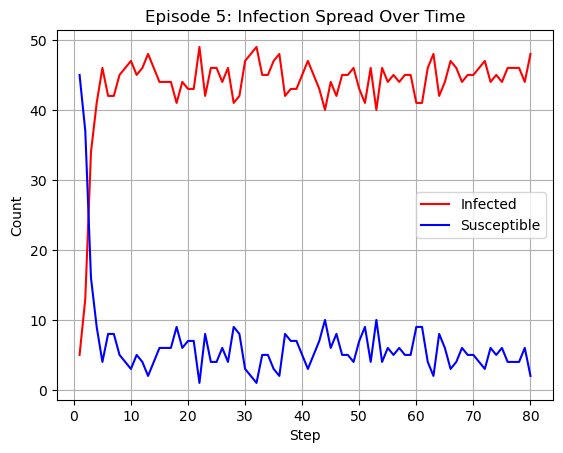

Action Dict: {'agent_a': 0, 'agent_b': 5}
Action Dict: {'agent_a': 35, 'agent_b': 23}
Action Dict: {'agent_a': 5, 'agent_b': 12}
Action Dict: {'agent_a': 3, 'agent_b': 37}
Action Dict: {'agent_a': 25, 'agent_b': 41}
Action Dict: {'agent_a': 4, 'agent_b': 31}
Action Dict: {'agent_a': 10, 'agent_b': 15}
Action Dict: {'agent_a': 3, 'agent_b': 44}
Action Dict: {'agent_a': 38, 'agent_b': 39}
Action Dict: {'agent_a': 5, 'agent_b': 18}
Step 90: 46 infected, 4 susceptible
  Rewards - Agent A: 0.88, Agent B: 0.16


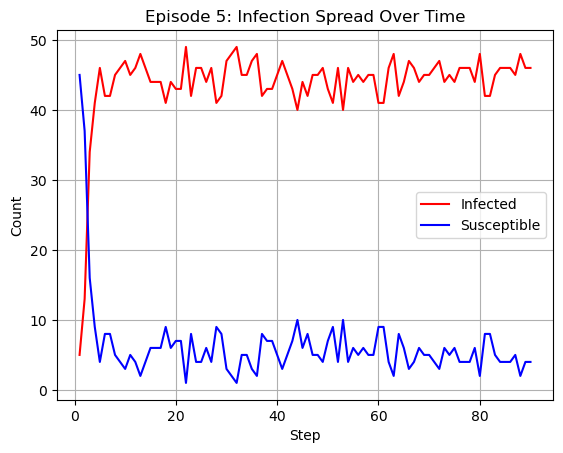

Action Dict: {'agent_a': 0, 'agent_b': 43}
Action Dict: {'agent_a': 21, 'agent_b': 16}
Action Dict: {'agent_a': 0, 'agent_b': 41}
Action Dict: {'agent_a': 3, 'agent_b': 19}
Action Dict: {'agent_a': 49, 'agent_b': 13}
Action Dict: {'agent_a': 39, 'agent_b': 41}
Action Dict: {'agent_a': 46, 'agent_b': 49}
Action Dict: {'agent_a': 39, 'agent_b': 49}
Action Dict: {'agent_a': 0, 'agent_b': 40}
Action Dict: {'agent_a': 5, 'agent_b': 6}
Step 100: 44 infected, 6 susceptible
  Rewards - Agent A: 0.84, Agent B: 0.24


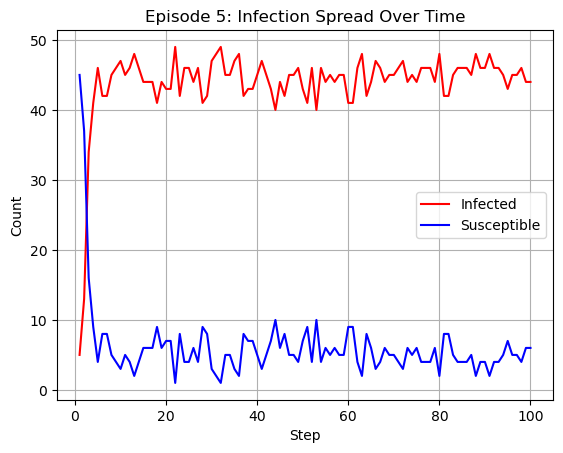


Episode ended at step 100
Maximum steps reached

--- Summary ---
Average episode length: 83.60 steps
Average final infection rate: 91.60%
Average Agent A (Spreader) total reward: 70.48
Average Agent B (Healer) total reward: 23.02


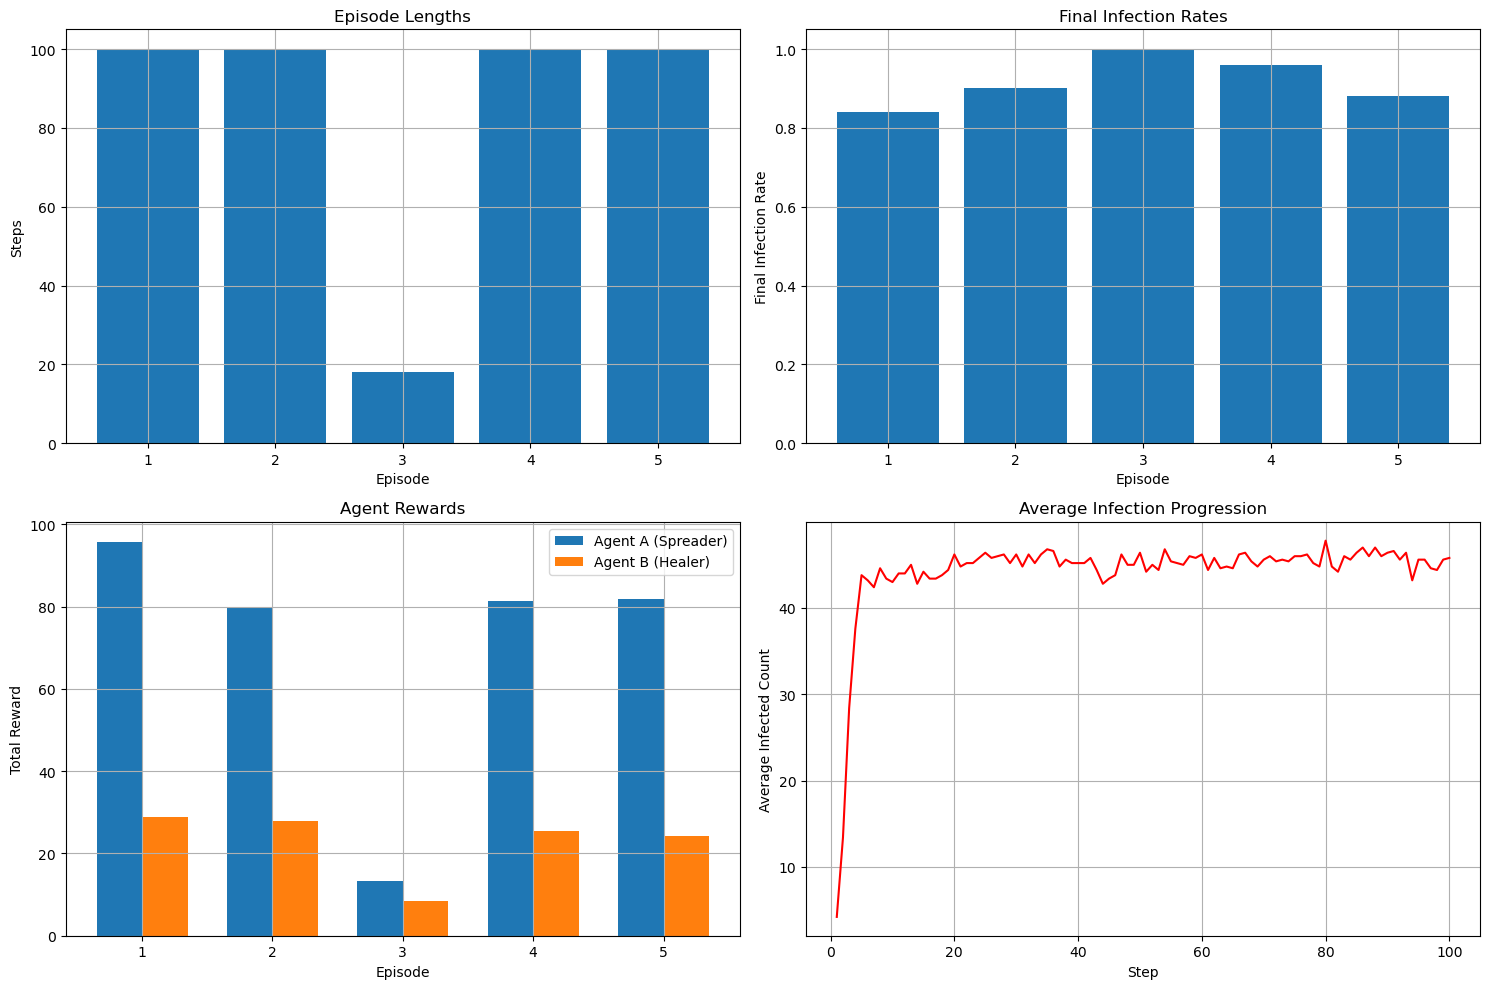

In [ ]:
def visualize_trained_agents(trained_policies, num_episodes=5, max_steps=100, network_size=50, edge_prob=0.2):
    """
    Visualize trained agents playing against each other in the environment.
    
    Args:
        trained_policies: Dictionary mapping agent IDs to trained policies
        num_episodes: Number of episodes to run
        max_steps: Maximum steps per episode
        network_size: Number of nodes in the network
        edge_prob: Probability of edge creation in Erdos-Renyi network
    """
    # Generate a new network for testing
    network = NetworkGenerator.erdos_renyi(network_size, edge_prob)
    
    # Initialize environment
    env_config = {
        "network": network,
        "infection_prob": 0.5,
        "recovery_prob": 0.1,
        "max_steps": max_steps
    }
    env = MultiAgentNetworkEnv(env_config)
    
    # Statistics for multiple episodes
    episode_lengths = []
    episode_infected_counts = []
    episode_rewards_a = []
    episode_rewards_b = []
    
    # Run multiple episodes
    for episode in range(num_episodes):
        print(f"\n--- Episode {episode+1}/{num_episodes} ---")
        
        # Reset environment
        obs, _ = env.reset()
        
        # Randomly select initial infection
        initial_infection = np.random.randint(0, network_size)
        env.env.network.nodes[initial_infection]['state'] = NodeState.INFECTED
        
        print(f"Network has {len(env.env.network.nodes())} nodes and {len(env.env.network.edges())} edges")
        print(f"Initially infected node: {initial_infection}")
        
        # Metrics to track for this episode
        step_infected_counts = []
        step_susceptible_counts = []
        total_reward_a = 0
        total_reward_b = 0
        
        # Print initial state
        print(f"Step 0: {env.env._get_infected_count()} infected, {env.env._get_susceptible_count()} susceptible")
        
        # Create figure for real-time plotting
        plt.figure(figsize=(12, 8))
        
        for step in range(1, max_steps + 1):
            # Get actions from trained policies
            action_a = trained_policies["agent_a"].compute_single_action(obs["agent_a"])[0]
            action_b = trained_policies["agent_b"].compute_single_action(obs["agent_b"])[0]
            
            # Execute step
            action_dict = {"agent_a": action_a, "agent_b": action_b}
            obs, rewards, dones, truncateds, infos = env.step(action_dict)
            
            # Track metrics
            infected_count = env.env._get_infected_count()
            susceptible_count = env.env._get_susceptible_count()
            step_infected_counts.append(infected_count)
            step_susceptible_counts.append(susceptible_count)
            total_reward_a += rewards["agent_a"]
            total_reward_b += rewards["agent_b"]
            
            # Print current state every 10 steps
            if step % 10 == 0 or step == 1:
                print(f"Step {step}: {infected_count} infected, {susceptible_count} susceptible")
                print(f"  Rewards - Agent A: {rewards['agent_a']:.2f}, Agent B: {rewards['agent_b']:.2f}")
            
            # Real-time plot update (optional, can be commented out for faster simulation)
            if step % 10 == 0:
                plt.clf()
                steps = range(1, len(step_infected_counts) + 1)
                plt.plot(steps, step_infected_counts, 'r-', label='Infected')
                plt.plot(steps, step_susceptible_counts, 'b-', label='Susceptible')
                plt.xlabel('Step')
                plt.ylabel('Count')
                plt.title(f'Episode {episode+1}: Infection Spread Over Time')
                plt.legend()
                plt.grid(True)
                plt.pause(0.01)
            
            # Break if done
            if dones["__all__"]:
                print(f"\nEpisode ended at step {step}")
                if infected_count == 0:
                    print("Infection eradicated - Healer (Agent B) wins!")
                elif susceptible_count == 0:
                    print("All nodes infected - Spreader (Agent A) wins!")
                else:
                    print("Maximum steps reached")
                break
        
        # Save episode statistics
        episode_lengths.append(step)
        episode_infected_counts.append(step_infected_counts)
        episode_rewards_a.append(total_reward_a)
        episode_rewards_b.append(total_reward_b)
        
        # Final plot for this episode
        plt.figure(figsize=(10, 6))
        steps = range(1, len(step_infected_counts) + 1)
        plt.plot(steps, step_infected_counts, 'r-', label='Infected')
        plt.plot(steps, step_susceptible_counts, 'b-', label='Susceptible')
        plt.xlabel('Step')
        plt.ylabel('Count')
        plt.title(f'Episode {episode+1}: Infection Spread Over Time')
        plt.legend()
        plt.grid(True)
        plt.savefig(f'episode_{episode+1}_spread.png')
        plt.close()
        
        # Network visualization (uncomment if you have implemented network.visualize())
        # env.env.render()
    
    # Summarize results
    print("\n--- Summary ---")
    print(f"Average episode length: {np.mean(episode_lengths):.2f} steps")
    print(f"Average final infection rate: {np.mean([counts[-1] for counts in episode_infected_counts])/network_size:.2%}")
    print(f"Average Agent A (Spreader) total reward: {np.mean(episode_rewards_a):.2f}")
    print(f"Average Agent B (Healer) total reward: {np.mean(episode_rewards_b):.2f}")
    
    # Plot summary across episodes
    plt.figure(figsize=(15, 10))
    
    # Plot 1: Episode lengths
    plt.subplot(2, 2, 1)
    plt.bar(range(1, num_episodes + 1), episode_lengths)
    plt.xlabel('Episode')
    plt.ylabel('Steps')
    plt.title('Episode Lengths')
    plt.grid(True)
    
    # Plot 2: Final infection rates
    plt.subplot(2, 2, 2)
    final_infection_rates = [counts[-1]/network_size for counts in episode_infected_counts]
    plt.bar(range(1, num_episodes + 1), final_infection_rates)
    plt.xlabel('Episode')
    plt.ylabel('Final Infection Rate')
    plt.title('Final Infection Rates')
    plt.grid(True)
    
    # Plot 3: Agent rewards
    plt.subplot(2, 2, 3)
    x = range(1, num_episodes + 1)
    width = 0.35
    plt.bar([i - width/2 for i in x], episode_rewards_a, width, label='Agent A (Spreader)')
    plt.bar([i + width/2 for i in x], episode_rewards_b, width, label='Agent B (Healer)')
    plt.xlabel('Episode')
    plt.ylabel('Total Reward')
    plt.title('Agent Rewards')
    plt.legend()
    plt.grid(True)
    
    # Plot 4: Average infection progression
    plt.subplot(2, 2, 4)
    # Find the max length and pad shorter episodes with their final values
    max_length = max(len(counts) for counts in episode_infected_counts)
    padded_counts = []
    for counts in episode_infected_counts:
        if len(counts) < max_length:
            padded = counts + [counts[-1]] * (max_length - len(counts))
        else:
            padded = counts
        padded_counts.append(padded)
    
    avg_infected = np.mean(padded_counts, axis=0)
    plt.plot(range(1, max_length + 1), avg_infected, 'r-')
    plt.xlabel('Step')
    plt.ylabel('Average Infected Count')
    plt.title('Average Infection Progression')
    plt.grid(True)
    
    plt.tight_layout()
    plt.savefig('summary_plots.png')
    plt.show()
    
    return {
        'episode_lengths': episode_lengths,
        'infected_counts': episode_infected_counts,
        'rewards_a': episode_rewards_a,
        'rewards_b': episode_rewards_b
    }

def evaluate_trained_agents():
    # Load the best checkpoint from your training
    checkpoint_path = results.get_best_checkpoint(
        trial=results.get_best_trial("episode_reward_mean", mode="max"),
        metric="episode_reward_mean",
        mode="max"
    )
    print(f"Loading checkpoint: {checkpoint_path}")
    
    # Create an Algorithm object from the checkpoint
    trained_algo = Algorithm.from_checkpoint(checkpoint_path)
    
    # Get the trained policies
    trained_policies = {
        "agent_a": trained_algo.get_policy("agent_a"),
        "agent_b": trained_algo.get_policy("agent_b")
    }
    
    # Run visualization and evaluation
    stats = visualize_trained_agents(
        trained_policies=trained_policies,
        num_episodes=5,
        max_steps=100, 
        network_size=50,
        edge_prob=0.2
    )
    
    return stats

evaluation_stats = evaluate_trained_agents()


# 4 - Experiment Setting 

# 5 - Experiments & Simulations

# 6 - Results

# TODO
- Implement local rate SIR. 
- Include length of infection in propagation logic. 
- Include skepticism in calculations. 
- Figure out how to perform community-wide actions. 

- *Refactor Multi-Agent Env code.* 
- Add echo chamber effect to recovery probabilities. 
- Add community-wide actions to simulations. 